# Residential house price prediction — end-to-end ML pipeline
### Dataset: *Ames Housing* (2930 houses, 80 features + target `SalePrice`)

This notebook implements a **modular and reproducible** Machine Learning pipeline
for predicting the sale price of residential properties in the city of Ames (Iowa),
starting from their physical, qualitative and contextual characteristics.

The whole work is organized into independent, documented phases, following good ML
development practices (separation of concerns, reusable functions, centralized
configuration, control of randomness).

---

## Project index

| Phase | Content |
|------|-----------|
| **1. Loading and understanding** | loading function, structure, data types, initial distributions |
| **2. Advanced data wrangling** | handling missing by nature, error correction, outlier removal |
| **2-EDA. Exploratory analysis** | correlations with price, feature–target relationships, categorical patterns |
| **3. Feature engineering & preprocessing** | categorical encoding, conditional scaling, derived features |
| **4. Modeling & optimization** | 3 models compared, hyperparameter tuning, K-fold CV |
| **5/final. Evaluation and interpretation** | unbiased estimate on the test set, residual analysis, comparative table, feature importance, pros and cons |

*All phases are implemented and executed. Right below, a plain-language summary;
further down, the technical sections with the code.*


---
## In summary: what we have done so far (in plain language)

*This section summarizes the work of Phases 1 and 2 in accessible language, before
diving into the technical detail. Meant to give the big picture at a glance.*

### Phase 1 — We "got to know" the data

Before building any model, we started by understanding **what we are working with**.
The dataset collects almost **3,000 houses sold** in the city of Ames, and for each one it
describes **80 different characteristics**: how large it is, what year it was built, what the
garage is like, the quality of the materials, the neighborhood, and so on. The goal is to use
this information to **predict the sale price**.

Three important things we discovered:

* **The information is of two kinds.** Some are numbers (the area, the year), others are
  categories (the type of neighborhood, the kitchen quality). They will need to be treated differently.
* **The word "NA" is misleading.** In many cases it does not mean "missing data", but
  "this house does not have that thing" — for example "NA" under pool simply means
  *no pool*. Understanding this is essential to avoid mistakes.
* **Prices are "skewed".** Most houses cost similar amounts, but a few very expensive
  mansions pull the average upward. That is why it is better to reason about price on a
  logarithmic scale, which "straightens out" this asymmetry and makes predictions more reliable.

### Phase 2 — We "cleaned" the data

A model learns well only from tidy data. So we fixed two problems:

* **The gaps in the data (missing values).** We filled them **according to the reason** they
  were missing. If they were missing because the house does not have that amenity (no garage, no
  fence), we explicitly wrote "absent". If instead it was a truly unrecorded value — like the
  width of the street frontage — we estimated it intelligently, using the typical value of the
  **houses in the same neighborhood**, which resemble each other. We also corrected an obvious
  typo (a garage "built in 2207").
* **The anomalous values (outliers).** We identified a few huge houses sold at a strangely
  low price: on closer inspection, they were **special sales** (new properties sold by the
  builder), not normal market sales. We removed them because they would confuse the model,
  **keeping instead** the expensive mansions whose high price was justified.

An important technical precaution we followed: when we "estimate" a missing value,
we do it in a way that does **not peek** at the data we will later use to judge the model.
It is like studying for an exam without having seen the questions first: only then is the final grade honest.

**Result:** we went from a raw dataset full of gaps to a **clean, complete and consistent**
table (2,927 houses, no missing data), ready for the next phases of analysis and
construction of the prediction model.

---


### Phase 2-EDA — We "explored" the data to find out what matters (in plain language)

Before building any model it is worth *looking* at the data and asking a few questions:
**which characteristics of a house really influence the price?** This phase is like the visit
of an appraiser who, before estimating, observes which factors make the difference.

We discovered, numbers in hand, that the price depends mostly on a few intuitive things:
the **overall quality** of materials and finishes (by far the strongest factor), the
**living area**, the size of the **basement** and the **garage**, and the **year of
construction**. We also saw that some characteristics "resemble" each other — for
example how many cars fit in the garage and how many square feet the garage has tell the same story
— a useful piece of information to avoid weighing the model down unnecessarily.

Finally we observed how the price changes as the "word-based" characteristics vary (such as the
neighborhood or the quality level): moving up a quality level, the price grows steadily and
markedly. All these observations guided our choices in the next phase, suggesting which
information was worth creating and combining.

---


### Phase 3 — We "prepared" the data for the model (in plain language)

A Machine Learning model does not "understand" words like *Excellent* or *neighborhood NAmes*,
and it struggles if numbers have very different scales from one another (square feet are in the
thousands, the number of bathrooms is 1 or 2). In this phase we therefore **translated and
tidied up** the data, and created new, more useful ones. Three things, concretely:

* **We translated words into numbers (encoding).** For qualities that have a natural order
  — *Poor < Fair < Good < Excellent* — we used an increasing scale, so the model understands
  that "Excellent" is worth more than "Good". For categories without an order — like the
  neighborhood name — we instead created many "yes/no" boxes (one per neighborhood), so as not to
  invent hierarchies that do not exist.
* **We put the numbers on the same scale (conditional scaling).** We standardized the
  magnitudes so that none prevails just because it is expressed in larger numbers. Where a
  value was very "skewed" (a few huge houses compared to many normal ones) we first
  applied a mathematical compression that makes it more balanced — hence "conditional":
  the adjustment kicks in *only* where needed.
* **We invented new, more telling information (derived features).** Instead of leaving the
  model to deduce them, we provide them ready-made: the **age of the house** (from the years
  of construction and sale), the **total area** by summing the various floors, the **total
  bathrooms**, the **space per room**, and an **overall quality score**. These are often the
  strongest clues to the price.

All of this was built as an automatic, reusable "**assembly line**":
the raw data enter on one side and come out ready for the model on the other, always in the
same way. And, as before, the line "learns" its rules **only from the training data**, to
guarantee an honest evaluation.

---


### Phase 4 — We "put several models to the test" (in plain language)

Now that the data is clean and well prepared, we can finally build the "brain"
that predicts prices. But which kind of brain works best? There is no single answer in
advance, so we **tried three different ones** and put them in a race:

* a **simple, linear** model, which looks for a direct formula "bigger/newer = more
  expensive". It is our reference point (the *baseline*): if the complex models do not beat it,
  we may as well keep the simple one.
* a **"forest" of decision trees** (*Random Forest*): hundreds of small rules of the kind
  "if the neighborhood is X and the area exceeds Y, then…", whose average gives a robust estimate.
* a **boosting** model (*XGBoost*), today among the most powerful: it builds the trees one after
  the other, and each learns to correct the errors of the previous one.

**How do we decide who wins, honestly?** It is not enough to try the model just once: you
risk being lucky. So we use **"cross-validation"** (*K-fold*): we split the houses into 5
groups, train the model on 4 and test it on the fifth, rotating the groups.
This way every house is used both to learn and to be checked, and we get an average grade
that is much more reliable.

Finally we did the **"fine tuning"**: each model has "knobs"
(how many rules, how deep, how fast it should learn…). We adjusted them
automatically by trying many combinations and keeping the best. The result is a clear
ranking of which model predicts prices with the smallest error.

---


### Phase 5/final — The final exam and the interpretation of the model (in plain language)

Throughout the whole construction we set aside, from the very beginning, a group of houses
(about 20%, **586 dwellings**) that the model **never saw**: neither to learn, nor to be
tuned. It is like keeping some questions hidden until exam day.

In this phase we bring out those houses and ask the model to predict their price "cold".
It is the acid test: if it does well even on houses it never saw, then it **did not simply
memorize** the training data, but captured rules that hold in general. We compare the error
on this "final exam" with the one estimated during training: if they are similar, the model is
solid and reliable.

Finally we look at the **residual errors** — by how much and in which direction it is wrong — to
make sure there are no systematic problems (for example always underestimating the most expensive
houses). It is the quality check that gives confidence before actually using the model.

---


### Phase 5/final (continued) — What the model does and which one to choose

Having a model that guesses prices is not enough: we also want to understand **why** it decides
the way it does and **which type of model is actually worth using**. Three things, concretely:

* **A side-by-side report card.** We placed the simple (linear) model and the more
  sophisticated tree-based one (XGBoost) next to each other, with their grades. This way you can
  see at a glance who predicts better and by how much.
* **What the model looks at most.** We asked the tree-based model (XGBoost) which
  characteristics weigh most in its decisions. No surprises: what matters most is the **overall
  quality** of the house, the **total area**, the **garage** and the presence of **air
  conditioning**. This is reassuring: the model "learned" the same things an experienced real
  estate agent would look at. Notably, many of the pieces of information that *we built* in the
  preparation phase (such as "quality times area") turn out to be among the most important:
  a sign that that work paid off.
* **Pros and cons of each model.** There is no absolutely perfect model: the simple one
  is very fast and easy to explain but captures fewer nuances; the tree-based one is more accurate and
  captures complex relationships, but is heavier and less transparent. We summarized these
  trade-offs to help choose based on needs (speed, accuracy, clarity).

In summary: we not only know *how* good the model is, but also *why* it is good and *when*
it is preferable to choose one over the other.

---


## 1.0 Setup and configuration

All configuration (paths, seeds, constants) is centralized in a single place,
to make the notebook reproducible and easy to adapt to other environments.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Centralized configuration -------------------------------------------
RANDOM_STATE = 42                 # single seed for the whole pipeline -> reproducibility
DATA_PATH = Path("AmesHousing.csv")
TARGET = "SalePrice"
ID_COLS = ["Order", "PID"]        # identifiers: non-predictive, excluded from the model

# --- Display settings ----------------------------------------
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(RANDOM_STATE)
print("Ambiente configurato. Seed =", RANDOM_STATE)

Ambiente configurato. Seed = 42


## 1.1 Data loading function

We wrap the loading in a dedicated function instead of calling `pd.read_csv`
scattered throughout the notebook. This ensures that **every time** the data is read
in the same way, and lets us centralize a few important choices.

**Design choice about missing values.**
In the Ames dataset the string `NA` has a twofold meaning and must be handled carefully:

* for many categorical features it means **"characteristic absent"** and *not* a missing value.
  Example: `Pool QC = NA` indicates *"the house has no pool"*, `Garage Type = NA` indicates
  *"no garage"*. These are valid pieces of information, not gaps in the data.
* for a few numeric features (e.g. `Lot Frontage`) it is instead a truly unrecorded value.

To avoid losing this distinction, we **disable the automatic conversion of `NA` into `NaN`**
at read time (`keep_default_na=False`) and we will handle missing values explicitly and
consciously in the pre-processing phase. The function still returns `NaN` only where it makes
semantic sense.


In [2]:
def load_data(path: Path = DATA_PATH, *, raw_na: bool = True) -> pd.DataFrame:
    """Loads the Ames Housing dataset in a reproducible way.

    Parameters
    ----------
    path : Path
        Path to the CSV file.
    raw_na : bool, default True
        If True keeps the original "NA" strings (semantic meaning:
        "feature absent"). If False lets pandas convert them to NaN.

    Returns
    -------
    pd.DataFrame
        The raw dataset, with only safe structural cleaning
        (stripping spaces in column names, trimming strings).
    """
    if not Path(path).exists():
        raise FileNotFoundError(f"File not found: {path}")

    # keep_default_na=False -> "NA" stays a string, does not become NaN automatically.
    # na_values=[""] -> only truly empty cells become NaN.
    read_kwargs = dict(keep_default_na=False, na_values=[""]) if raw_na else {}
    df = pd.read_csv(path, **read_kwargs)

    # Safe structural cleaning (does not alter values, only the form):
    df.columns = df.columns.str.strip()                       # column names without spaces
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())  # trim text values

    return df


# Load data
df = load_data()
print(f"Dataset loaded successfully: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded successfully: 2930 rows x 82 columns


/tmp/ipykernel_615/2178821965.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NA,NA,NA,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NA,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NA,NA,NA,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


## 1.2 Dataset structure: dimensions and data types

Before any statistical analysis we look at the "shape" of the dataset: how many
observations, how many variables, of what type. We build a reusable summary function.


In [3]:
def dataset_overview(df: pd.DataFrame) -> None:
    """Prints a high-level structural summary of the DataFrame."""
    n_rows, n_cols = df.shape
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include="object").columns
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2

    print("=" * 55)
    print(f"{'Observations (rows)':<35}{n_rows:>20}")
    print(f"{'Variables (columns)':<35}{n_cols:>20}")
    print(f"{'  - numeric':<35}{len(num_cols):>20}")
    print(f"{'  - categorical / text':<35}{len(cat_cols):>20}")
    print(f"{'Target variable':<35}{TARGET:>20}")
    print(f"{'Memory usage (MB)':<35}{mem_mb:>20.2f}")
    print("=" * 55)


dataset_overview(df)

Observations (rows)                                2930
Variables (columns)                                  82
  - numeric                                          39
  - categorical / text                               43
Target variable                               SalePrice
Memory usage (MB)                                  7.19


/tmp/ipykernel_615/372992816.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


We look at the exact breakdown of types and isolate the identifier columns,
which will be excluded from modeling because they carry no predictive information
(`Order` is a simple progressive index, `PID` is the property's cadastral code).


In [4]:
print("Count by data type:")
print(df.dtypes.value_counts().to_string())

print("\nIdentifier columns (to exclude from the model):")
for c in ID_COLS:
    print(f"  - {c}: {df[c].nunique()} unique values out of {len(df)} rows")

Count by data type:
str        43
int64      28
float64    11

Identifier columns (to exclude from the model):
  - Order: 2930 unique values out of 2930 rows
  - PID: 2930 unique values out of 2930 rows


## 1.3 Data dictionary (per-column profile)

With 80 variables, scrolling through the columns by hand is inefficient. We build a
**data dictionary** generated automatically: for each column it reports type,
number of distinct values, percentage of missing and some example values.
It is a working tool we will reuse to decide pre-processing strategies.


In [5]:
def build_data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    """Generates a concise profile for each column of the DataFrame.

    For each variable it reports: dtype, number of distinct values,
    count and percentage of missing values (real NaN), and
    a sample of observed values.
    """
    profile = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(dropna=True),
        "n_missing": df.isna().sum(),
    })
    profile["pct_missing"] = (profile["n_missing"] / len(df) * 100).round(2)
    profile["sample_values"] = [
        ", ".join(map(str, df[c].dropna().unique()[:4]))
        for c in df.columns
    ]
    return profile.sort_values("pct_missing", ascending=False)


data_dict = build_data_dictionary(df)
print(f"Dizionario dati: {data_dict.shape[0]} variabili profilate.")
data_dict.head(20)

Dizionario dati: 82 variabili profilate.


,dtype,n_unique,n_missing,pct_missing,sample_values
Lot Frontage,float64,128,490,16.72,"141.0, 80.0, 81.0, 93.0"
Garage Yr Blt,float64,103,159,5.43,"1960.0, 1961.0, 1958.0, 1968.0"
Mas Vnr Area,float64,445,23,0.78,"112.0, 0.0, 108.0, 20.0"
Mas Vnr Type,str,5,23,0.78,"Stone, None, BrkFace, BrkCmn"
Bsmt Exposure,str,5,4,0.14,"Gd, No, Mn, Av"
Bsmt Full Bath,float64,4,2,0.07,"1.0, 0.0, 2.0, 3.0"
BsmtFin Type 2,str,7,2,0.07,"Unf, LwQ, BLQ, Rec"
Garage Finish,str,4,2,0.07,"Fin, Unf, RFn, NA"
Bsmt Half Bath,float64,3,2,0.07,"0.0, 1.0, 2.0"
BsmtFin SF 2,float64,274,1,0.03,"0.0, 144.0, 1120.0, 163.0"


## 1.4 Missing values: distinguishing "absent" from "unrecorded"

As anticipated, here lies one of the main pitfalls of the Ames dataset. We quantify
the *real* `NaN` (empty cells in the CSV) and separately show the cases in which the string
`"NA"` is instead an informative value ("feature absent").


In [6]:
# 1) Real NaN (empty cells) -- these are the true missing values to handle
real_missing = df.isna().sum()
real_missing = real_missing[real_missing > 0].sort_values(ascending=False)

print(f"Columns with REAL NaN (empty cells): {len(real_missing)}")
print(real_missing.to_string())

# 2) Semantic "NA" string ("feature absent"): count per column
na_semantic = (df == "NA").sum()
na_semantic = na_semantic[na_semantic > 0].sort_values(ascending=False)

print(f"\nColumns where \"NA\" means FEATURE ABSENT (not a missing value): {len(na_semantic)}")
print(na_semantic.head(12).to_string())

Columns with REAL NaN (empty cells): 21
Lot Frontage      490
Garage Yr Blt     159
Mas Vnr Type       23
Mas Vnr Area       23
Bsmt Exposure       4
Garage Finish       2
Bsmt Half Bath      2
Bsmt Full Bath      2
BsmtFin Type 2      2
Bsmt Cond           1
Bsmt Qual           1
BsmtFin Type 1      1
BsmtFin SF 1        1
Electrical          1
Total Bsmt SF       1
Bsmt Unf SF         1
BsmtFin SF 2        1
Garage Cars         1
Garage Area         1
Garage Qual         1
Garage Cond         1

Columns where "NA" means FEATURE ABSENT (not a missing value): 14
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Fireplace Qu      1422
Garage Qual        158
Garage Cond        158
Garage Finish      157
Garage Type        157
BsmtFin Type 2      79
Bsmt Qual           79
BsmtFin Type 1      79


**Reading the result.** The columns with semantic `"NA"` (`Pool QC`, `Misc Feature`,
`Alley`, `Fence`, `Garage *`, `Bsmt *`, ...) describe the **absence of an amenity**:
they will be turned into an explicit category (e.g. `"None"`) and *not* imputed.
The few real `NaN` (mainly `Lot Frontage`, `Mas Vnr Area`, `Garage Yr Blt`)
are instead unrecorded values, to be imputed in the pre-processing phase.
Distinguishing the two cases avoids introducing bias and losing information.


## 1.5 Distribution of the target variable (`SalePrice`)

Understanding the target is essential: its distribution drives the choice of the
metric, the possible transformation and the interpretation of the results.


In [7]:
price = df[TARGET]

stats = {
    "Count": price.count(),
    "Mean": price.mean(),
    "Median": price.median(),
    "Std. dev.": price.std(),
    "Minimum": price.min(),
    "Maximum": price.max(),
    "Skewness": price.skew(),
    "Kurtosis": price.kurt(),
}
for k, v in stats.items():
    print(f"{k:<20}{v:>15,.2f}")

Count                      2,930.00
Mean                     180,796.06
Median                   160,000.00
Std. dev.                 79,886.69
Minimum                   12,789.00
Maximum                  755,000.00
Skewness                       1.74
Kurtosis                       5.12


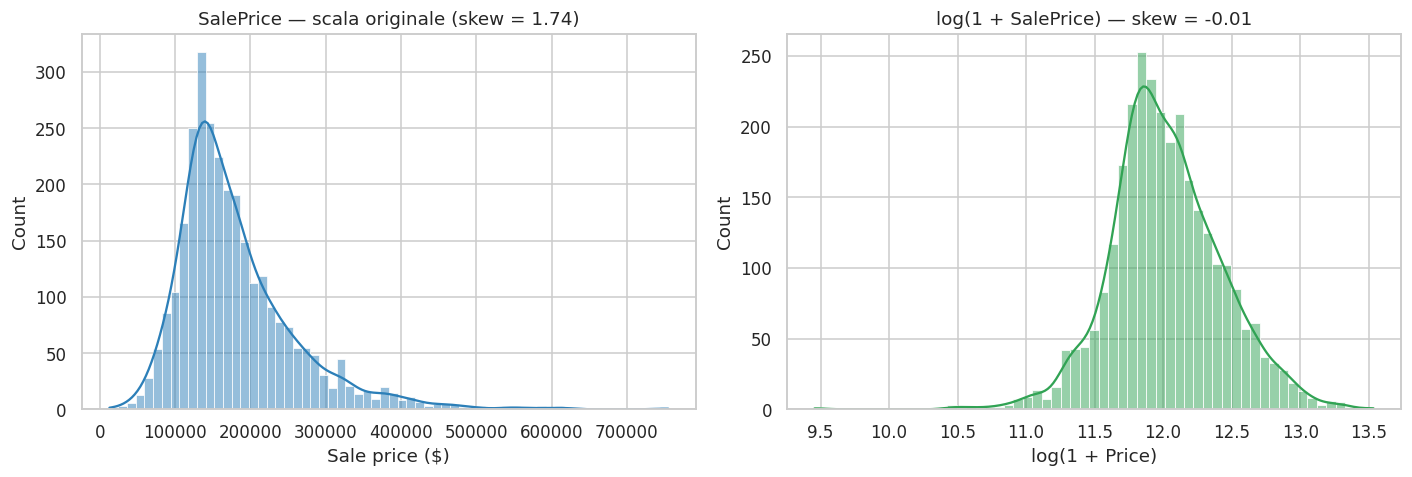

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Original distribution: clearly right-skewed
sns.histplot(price, kde=True, ax=axes[0], color="#2c7fb8")
axes[0].set_title(f"SalePrice — scala originale (skew = {price.skew():.2f})")
axes[0].set_xlabel("Sale price ($)")

# Log distribution: very close to normal
sns.histplot(np.log1p(price), kde=True, ax=axes[1], color="#31a354")
axes[1].set_title(f"log(1 + SalePrice) — skew = {np.log1p(price).skew():.2f}")
axes[1].set_xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()

**Operational conclusion.** `SalePrice` is strongly right-skewed
(skew ≈ 1.74): a few very expensive houses stretch the tail. The
logarithmic transformation `log(1 + SalePrice)` makes the distribution almost symmetric (skew ≈ 0.04).
For this reason, in the next phases, **we will model the logarithm of the price** and evaluate
with the RMSE metric on the log — consistent with the official metric of the Ames competition
and less sensitive to extreme-value properties.


## 1.6 Initial feature distributions

An overall look at the distributions: some key numeric variables and the
cardinality of the categorical variables. It serves to get a sense of scale, skewness
and variety before the in-depth EDA (Phase 2).


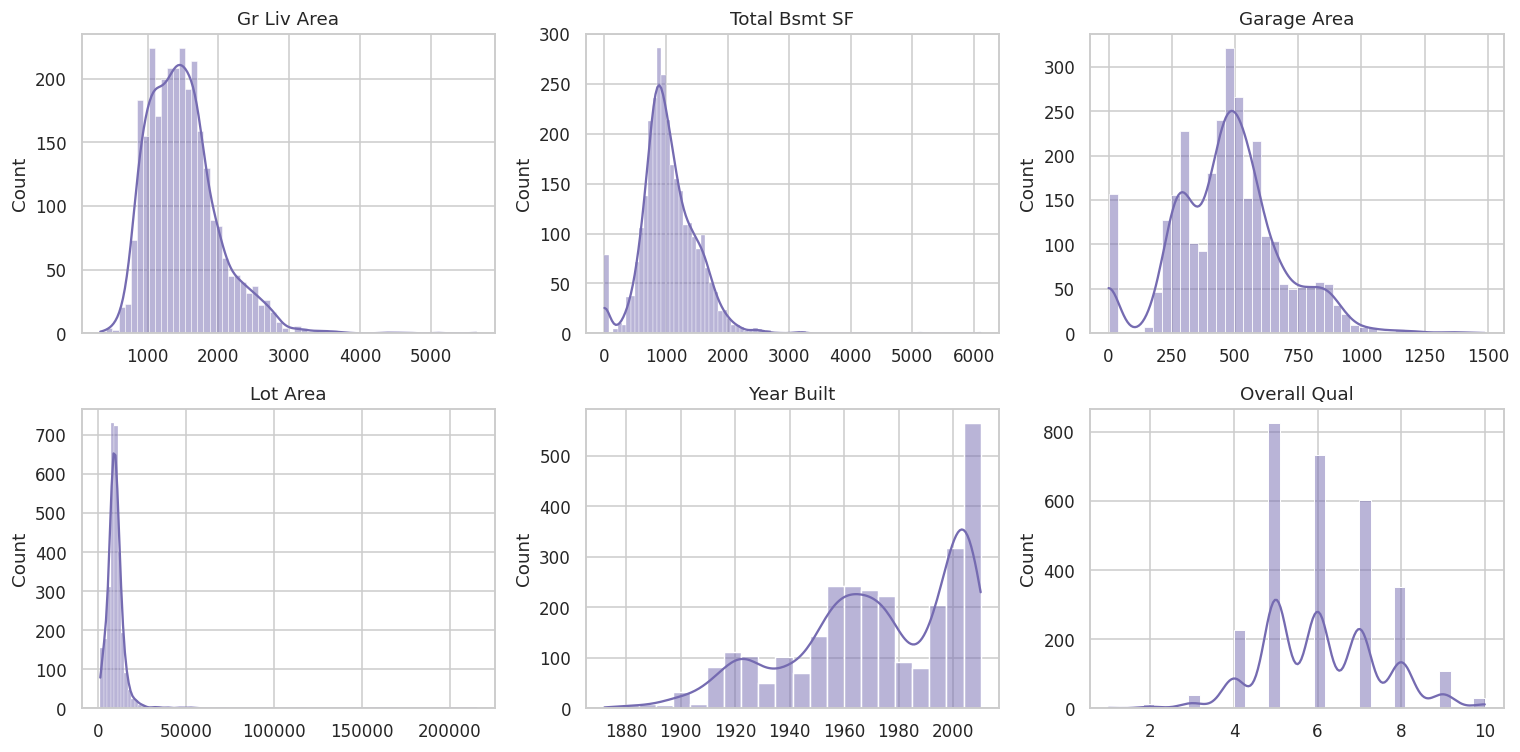

In [9]:
# Some of the numeric features most relevant to a property's price
key_numeric = ["Gr Liv Area", "Total Bsmt SF", "Garage Area",
               "Lot Area", "Year Built", "Overall Qual"]
key_numeric = [c for c in key_numeric if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), key_numeric):
    sns.histplot(df[col], kde=True, ax=ax, color="#756bb1")
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [10]:
# Cardinality of categorical variables: how many categories does each have?
cat_cols = df.select_dtypes(include="object").columns
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

print("Categorical variables by number of distinct categories:")
print(cardinality.to_string())
print(f"\nTotal categorical variables: {len(cat_cols)}")
print(f"Average cardinality: {cardinality.mean():.1f} | max: {cardinality.max()} "
      f"({cardinality.idxmax()})")

Categorical variables by number of distinct categories:
Neighborhood      28
Exterior 2nd      17
Exterior 1st      16
Sale Type         10
Condition 1        9
House Style        8
Functional         8
Roof Matl          8
Condition 2        8
MS Zoning          7
BsmtFin Type 1     7
Garage Type        7
BsmtFin Type 2     7
Sale Condition     6
Misc Feature       6
Fireplace Qu       6
Bsmt Cond          6
Roof Style         6
Garage Cond        6
Garage Qual        6
Heating            6
Bsmt Qual          6
Foundation         6
Bldg Type          5
Bsmt Exposure      5
Lot Config         5
Heating QC         5
Fence              5
Pool QC            5
Kitchen Qual       5
Electrical         5
Mas Vnr Type       5
Exter Cond         5
Land Contour       4
Lot Shape          4
Exter Qual         4
Garage Finish      4
Alley              3
Utilities          3
Paved Drive        3
Land Slope         3
Street             2
Central Air        2

Total categorical variables: 43
Average 

/tmp/ipykernel_615/2996602254.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


**Phase 1 summary.**

* The dataset has **2930 observations** and **82 columns**: 80 predictive features,
  1 target (`SalePrice`) and the identifiers `Order`/`PID` to discard.
* The variables split into **~39 numeric** and **~43 categorical**: the pipeline
  will have to treat the two groups differently (encoding vs scaling).
* The "missing values" are of **two different natures**: semantic absence of an amenity
  (to be encoded as a category) and truly unrecorded values (to be imputed).
* The **target is skewed**: we will work on its logarithm.

With this structural understanding we can proceed, in the next phase,
to the exploratory analysis of the relationships between the features and the price.


---
# Phase 2 — Advanced Data Wrangling

Building on the structural understanding from Phase 1, we clean the dataset by handling
**missing values** and **outliers**. We adopt a fundamental guiding principle to avoid
*data leakage*:

> We distinguish the **deterministic fixes** (which use neither cross-row statistics nor the target)
> from the **statistical imputations** (which estimate a value from other observations).
> The former are safe to apply to the whole dataset; the latter, in a rigorous pipeline,
> must be *learned only on the training set*. We design the functions to be consistent with
> this distinction and reusable in the final pipeline (Phase 3–4).


## 2.1 Reasoned map of the missing values

From the Phase 1 analysis the missing values fall into **three categories**, each with a
different strategy. We encode them explicitly as configuration, so the logic
is readable and verifiable.


In [11]:
# --- Category A: categorical "NA" = FEATURE ABSENT -> becomes category "None" ----
# (e.g. Pool QC=NA -> no pool). Deterministic fix, no leakage.
SEMANTIC_NONE_CAT = [
    "Alley", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
    "BsmtFin Type 1", "BsmtFin Type 2", "Fireplace Qu",
    "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
    "Pool QC", "Fence", "Misc Feature", "Mas Vnr Type",
]

# --- Category B: STRUCTURALLY absent numerics -> 0 ---------------------------
# (no garage/basement => area, baths, car spaces = 0). Deterministic.
STRUCTURAL_ZERO_NUM = [
    "Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
    "Total Bsmt SF", "Bsmt Full Bath", "Bsmt Half Bath",
    "Garage Cars", "Garage Area",
]

# --- Category C: TRUE missing values to impute statistically ------------------------
#   Lot Frontage -> median by Neighborhood: captures the urban regularity
#   Electrical   -> mode (only 1 missing)
#   Garage Yr Blt-> dedicated handling (see below)
STAT_IMPUTE = ["Lot Frontage", "Electrical", "Garage Yr Blt"]

print("Category A (semantic NA -> 'None'):", len(SEMANTIC_NONE_CAT), "columns")
print("Category B (structural -> 0):       ", len(STRUCTURAL_ZERO_NUM), "columns")
print("Category C (statistical imputation):", len(STAT_IMPUTE), "columns")

Category A (semantic NA -> 'None'): 15 columns
Category B (structural -> 0):        9 columns
Category C (statistical imputation): 3 columns


## 2.2 Deterministic fixes (safe, no leakage)

These operations depend neither on statistics computed over other rows nor on the target:
they are simple encoding rules and corrections of obvious errors. They are therefore safe
to apply to the whole dataset.


In [12]:
def fix_deterministic(df: pd.DataFrame) -> pd.DataFrame:
    """Applies the deterministic fixes for missing values and known errors.

    - Category A: "NA"/NaN in the listed categoricals -> "None" (feature absent)
    - Category B: NaN in structural numerics -> 0 (amenity absent)
    - Fix for known data-entry errors (e.g. Garage Yr Blt = 2207 -> 2007)
    Introduces no data leakage: no cross-row statistics, no use of the target.
    """
    df = df.copy()

    # Category A: the "NA" string and any NaN become the "None" category
    for col in SEMANTIC_NONE_CAT:
        df[col] = df[col].replace("NA", "None").fillna("None")

    # Category B: structural missing numerics -> 0
    for col in STRUCTURAL_ZERO_NUM:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Fix known error: garage year 2207 (impossible) -> 2007 (obvious typo)
    if "Garage Yr Blt" in df.columns:
        gyb = pd.to_numeric(df["Garage Yr Blt"], errors="coerce")
        df["Garage Yr Blt"] = gyb.where(gyb <= 2010, 2007)

    return df


df_clean = fix_deterministic(df)
print("Deterministic fixes applied.")
print("Residual NaN after Category A+B:", int(df_clean[SEMANTIC_NONE_CAT + STRUCTURAL_ZERO_NUM].isna().sum().sum()))

Deterministic fixes applied.
Residual NaN after Category A+B: 0


## 2.3 Statistical imputation (pipeline-ready)

`Lot Frontage` (490 missing) is the lot's street-frontage footage: it is strongly
tied to the **neighborhood** (lots in the same block have similar frontages). We therefore impute it
with the **median by `Neighborhood`**, much more accurate than the global median.

Since this imputation *learns statistics from the data*, we wrap it in a function
that **separates learning (`fit`) from application (`transform`)**: the values are
estimated on a reference set (in production: the training set only) and then applied.
This makes it directly integrable into the final pipeline without leakage.


In [13]:
def fit_group_medians(df: pd.DataFrame, col: str, by: str) -> dict:
    """Learns the medians of `col` grouped by `by` (e.g. neighborhood).
    In a pipeline it must be called ONLY on the training set."""
    medians = df.groupby(by)[col].median()
    return {"by": by, "col": col,
            "medians": medians.to_dict(),
            "global": df[col].median()}


def apply_group_medians(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """Applies the learned group medians; uses the global median as fallback."""
    df = df.copy()
    col, by = params["col"], params["by"]
    fill = df[by].map(params["medians"]).fillna(params["global"])
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(fill)
    return df


# Lot Frontage: median by neighborhood
lf_params = fit_group_medians(df_clean, "Lot Frontage", "Neighborhood")
df_clean = apply_group_medians(df_clean, lf_params)

# Electrical: mode (most common electrical system)
electrical_mode = df_clean["Electrical"].mode(dropna=True)[0]
df_clean["Electrical"] = df_clean["Electrical"].replace("NA", np.nan).fillna(electrical_mode)

# Garage Yr Blt: where there is no garage (Garage Type == "None") the year does not exist -> 0
#  + explicit "has garage" flag so 0 is not confused with a real year
no_garage = df_clean["Garage Type"] == "None"
df_clean["Has Garage"] = (~no_garage).astype(int)
df_clean["Garage Yr Blt"] = df_clean["Garage Yr Blt"].fillna(0)

print(f"Lot Frontage imputed with median by neighborhood "
      f"(global fallback = {lf_params['global']:.0f}).")
print(f"Electrical: {electrical_mode} (mode). Garage Yr Blt: 0 where absent + 'Has Garage' flag.")

Lot Frontage imputed with median by neighborhood (global fallback = 68).
Electrical: SBrkr (mode). Garage Yr Blt: 0 where absent + 'Has Garage' flag.


In [14]:
# Final check: no residual missing values
remaining = df_clean.isna().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("OK - No residual missing values in the dataset.")
else:
    print("Warning, residual missing values:")
    print(remaining.to_string())

OK - No residual missing values in the dataset.


## 2.4 Outlier handling

For outliers we focus on the strongest and most interpretable relationship in the dataset:
**living area (`Gr Liv Area`) vs price (`SalePrice`)**. The dataset's author
(De Cock, 2011) explicitly flags a few anomalous observations among the very large houses.


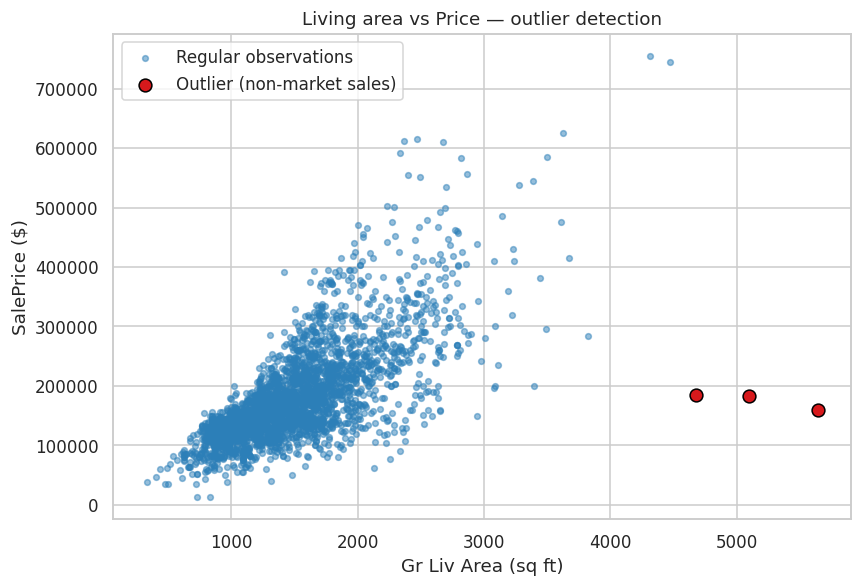

Outlier candidates (Gr Liv Area > 4000 and price < 300k):
      Gr Liv Area  SalePrice Sale Condition  Overall Qual
1498         5642     160000        Partial            10
2180         5095     183850        Partial            10
2181         4676     184750        Partial            10


In [15]:
fig, ax = plt.subplots(figsize=(8, 5.5))
gla = pd.to_numeric(df_clean["Gr Liv Area"])
price = df_clean[TARGET]

mask_out = (gla > 4000) & (price < 300000)   # large but low-priced
ax.scatter(gla[~mask_out], price[~mask_out], s=14, alpha=0.5,
           color="#2c7fb8", label="Regular observations")
ax.scatter(gla[mask_out], price[mask_out], s=70, color="#d7191c",
           edgecolor="black", label="Outlier (non-market sales)")
ax.set_xlabel("Gr Liv Area (sq ft)")
ax.set_ylabel("SalePrice ($)")
ax.set_title("Living area vs Price — outlier detection")
ax.legend()
plt.tight_layout()
plt.show()

print("Outlier candidates (Gr Liv Area > 4000 and price < 300k):")
print(df_clean.loc[mask_out, ["Gr Liv Area", TARGET, "Sale Condition", "Overall Qual"]].to_string())

**Removal criterion — a *data quality* choice, not a statistical one.**

The highlighted houses have `Sale Condition = Partial`: they are **non-market sales**
(newly built properties, sold by the builder before completion). Their price
does not reflect the market value and breaks the area–price relationship. We remove them
because they *are not valid transactions* for our goal, not because they are "outliers"
in a statistical sense.

The two 745k–755k mansions with large area are **not** removed: their prices
are consistent with their quality, hence legitimate signal.

> Note on rigor: removing rows is a *data cleaning* operation based on a
> domain rule (non-market sales), and as such it is legitimate on the whole dataset.
> A purely *statistical* outlier removal (e.g. z-score/IQR thresholds) would instead
> need to be estimated only on the training set so as not to bias the evaluation.


In [16]:
def remove_nonmarket_outliers(df: pd.DataFrame, *, area_thr: float = 4000,
                              price_thr: float = 300000) -> pd.DataFrame:
    """Removes anomalous non-market sales (large area at low price).

    Domain rule based on De Cock (2011) documentation: a few `Partial` houses
    with very large Gr Liv Area and low price are not valid transactions.
    """
    df = df.copy()
    area = pd.to_numeric(df["Gr Liv Area"])
    mask = (area > area_thr) & (df[TARGET] < price_thr)
    n_removed = int(mask.sum())
    df = df.loc[~mask].reset_index(drop=True)
    print(f"Outliers removed: {n_removed}  |  rows: {len(df)+n_removed} -> {len(df)}")
    return df


df_clean = remove_nonmarket_outliers(df_clean)

Outliers removed: 3  |  rows: 2930 -> 2927


## 2.5 End-to-end wrangling function

We compose the previous functions into a single reusable wrangling pipeline.
We separate the learned parameters (neighborhood medians, mode, thresholds) so that, in
modeling, they can be estimated on the training set only and applied to the test.


In [17]:
def wrangle(df: pd.DataFrame, *, impute_params: dict | None = None,
            drop_outliers: bool = True) -> tuple[pd.DataFrame, dict]:
    """End-to-end data wrangling pipeline.

    Parameters
    ----------
    df : raw DataFrame (output of load_data).
    impute_params : if None, the imputation statistics are LEARNED from `df`
        (training mode). If provided, they are REUSED (test/production mode).
    drop_outliers : if True removes non-market sales (training only).

    Returns
    -------
    (df_wrangled, impute_params) : the cleaned dataset and the learned/reused parameters.
    """
    df = fix_deterministic(df)

    fit_mode = impute_params is None
    if fit_mode:
        impute_params = {
            "lot_frontage": fit_group_medians(df, "Lot Frontage", "Neighborhood"),
            "electrical_mode": df["Electrical"].mode(dropna=True)[0],
        }

    df = apply_group_medians(df, impute_params["lot_frontage"])
    df["Electrical"] = (df["Electrical"].replace("NA", np.nan)
                        .fillna(impute_params["electrical_mode"]))
    df["Has Garage"] = (df["Garage Type"] != "None").astype(int)
    df["Garage Yr Blt"] = pd.to_numeric(df["Garage Yr Blt"], errors="coerce").fillna(0)

    if drop_outliers and fit_mode:
        df = remove_nonmarket_outliers(df)

    return df, impute_params


# --- Split BEFORE statistical imputation, to avoid data leakage ---
from sklearn.model_selection import train_test_split

df_raw = load_data()
train_raw, test_raw = train_test_split(df_raw, test_size=0.2, random_state=RANDOM_STATE)

# wrangle() LEARNS the statistics (medians by neighborhood, mode) ONLY on training
# and removes outliers only from training; then RE-APPLIES the same parameters to the test.
train_wr, learned_params = wrangle(train_raw)
test_wr, _ = wrangle(test_raw, impute_params=learned_params, drop_outliers=False)

# From here on 'df_wrangled' refers to the TRAINING data: EDA, column profiling
# and model fitting happen on these. The test set stays separate until the final evaluation.
df_wrangled = train_wr

print(f"Training (post-wrangling): {train_wr.shape}")
print(f"Test (post-wrangling, held out): {test_wr.shape}")
print("Missing values — train:", int(train_wr.isna().sum().sum()),
      "| test:", int(test_wr.isna().sum().sum()))
print("Imputations learned ONLY on training: no data leakage.")

Outliers removed: 2  |  rows: 2344 -> 2342
Training (post-wrangling): (2342, 83)
Test (post-wrangling, held out): (586, 83)
Missing values — train: 0 | test: 0
Imputations learned ONLY on training: no data leakage.


/tmp/ipykernel_615/2178821965.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


**Phase 2 summary.**

* Missing values were handled by **nature**: explicit `"None"` encoding for absent
  amenities, `0` for structural numerics, **neighborhood imputation** for `Lot Frontage`,
  mode for `Electrical`.
* Fixed the data-entry error `Garage Yr Blt = 2207` and added the `Has Garage` flag.
* Removed a few **non-market sales** (`Partial`, large area, low price) that
  distort the area–price relationship, while keeping the legitimate expensive mansions.
* Everything is wrapped in `wrangle()`, designed to **learn on training** and
  **re-apply on test** without data leakage — ready for the modeling pipeline.

The dataset is now clean and consistent, ready for exploratory analysis and feature engineering.


---
# Phase 2-EDA — Exploratory Data Analysis

Before feature engineering, we explore the *clean* dataset (output of Phase 2) to understand
**which variables are related to the price** and **how**. EDA does not modify the data: it serves to generate
insights that will guide the modeling choices. We work on `df_wrangled`.


## 2-EDA.1 Correlations with the price

We quantify the linear relationship between each numeric variable and `SalePrice` via the
Pearson correlation coefficient. It is a first filter to identify the strongest predictors.


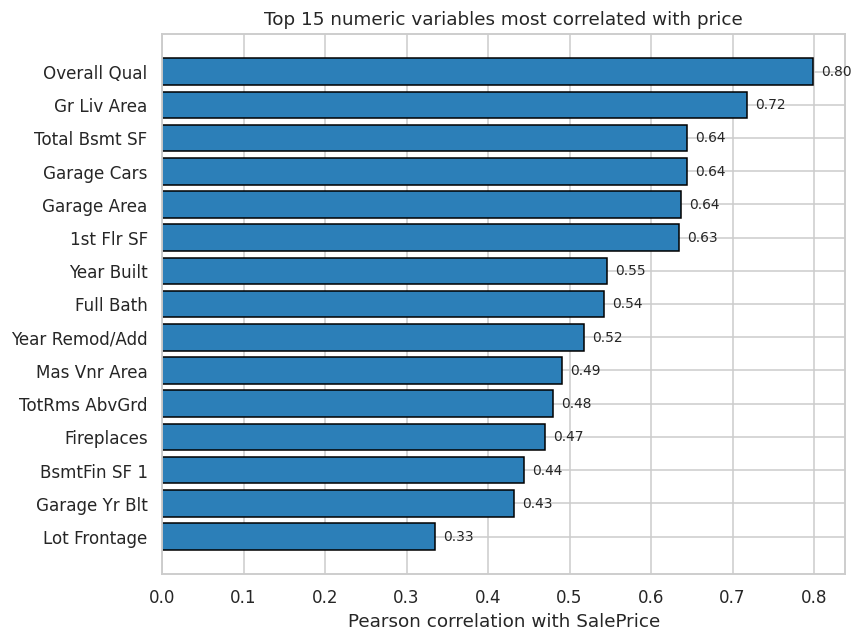

Most correlated variables (positive):
Overall Qual      0.798
Gr Liv Area       0.717
Total Bsmt SF     0.645
Garage Cars       0.644
Garage Area       0.637
1st Flr SF        0.634
Year Built        0.546
Full Bath         0.542
Year Remod/Add    0.518
Mas Vnr Area      0.491
TotRms AbvGrd     0.480
Fireplaces        0.470
BsmtFin SF 1      0.444
Garage Yr Blt     0.432
Lot Frontage      0.335


In [18]:
num_df = df_wrangled.select_dtypes(include="number").drop(columns=ID_COLS, errors="ignore")
corr_target = (num_df.corr(numeric_only=True)[TARGET]
               .drop(TARGET).sort_values(ascending=False))

top_pos = corr_target.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_pos.index[::-1], top_pos.values[::-1], color="#2c7fb8", edgecolor="black")
ax.set_xlabel("Pearson correlation with SalePrice")
ax.set_title("Top 15 numeric variables most correlated with price")
for i, v in enumerate(top_pos.values[::-1]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Most correlated variables (positive):")
print(top_pos.round(3).to_string())

**Overall quality** (`Overall Qual`) is by far the strongest predictor, followed
by the **area** measures (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`) and the **garage**
amenities. This confirms real estate intuition and anticipates which derived features to build.


## 2-EDA.2 Correlation map and multicollinearity

A heatmap among the most relevant variables reveals not only the link with the price, but also the
**redundancies among predictors** (multicollinearity): variables highly correlated with each other carry
overlapping information.


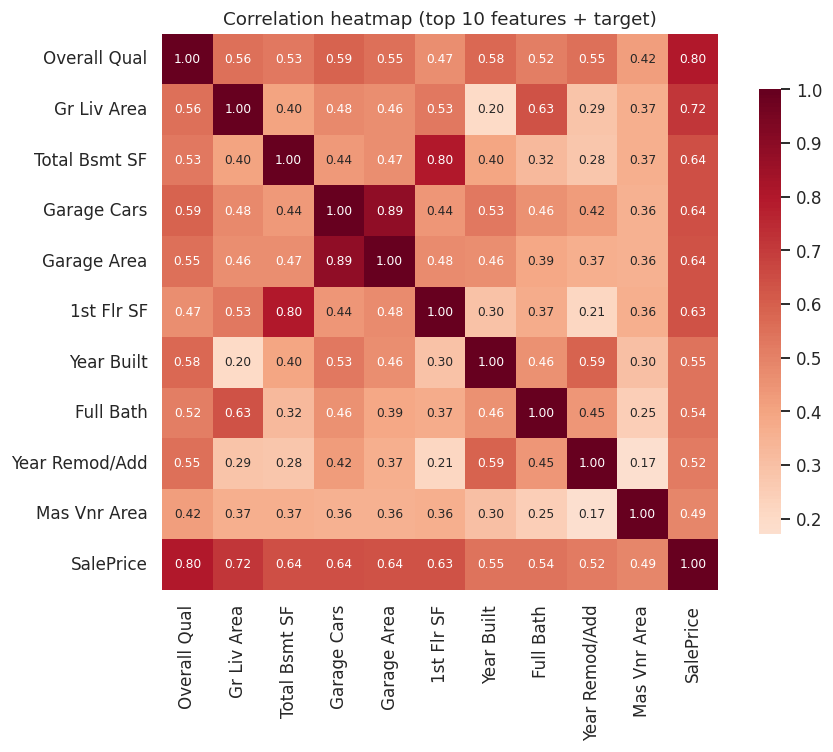

Pairs of strongly correlated predictors (|r| > 0.7):
  Total Bsmt SF <-> 1st Flr SF: 0.8
  Garage Cars <-> Garage Area: 0.89


In [19]:
top_feats = corr_target.head(10).index.tolist() + [TARGET]
corr_matrix = num_df[top_feats].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation heatmap (top 10 features + target)")
plt.tight_layout()
plt.show()

# Pairs of strongly correlated predictors (possible redundancy)
import itertools
pairs = []
for a, b in itertools.combinations(corr_target.head(10).index, 2):
    r = num_df[a].corr(num_df[b])
    if abs(r) > 0.7:
        pairs.append((a, b, round(r, 2)))
print("Pairs of strongly correlated predictors (|r| > 0.7):")
for a, b, r in pairs:
    print(f"  {a} <-> {b}: {r}")

Expected redundancies emerge: for example `Garage Cars` and `Garage Area` (both describe the
garage capacity) or `Total Bsmt SF` and `1st Flr SF`. This is a useful indication: linear models
benefit from regularization (Ridge, Phase 4) precisely to handle this multicollinearity.


## 2-EDA.3 Relationships between the main features and the price

The scatter plots show the *shape* of the relationship (linear? curved? with outliers?) between the
strongest predictors and the price.


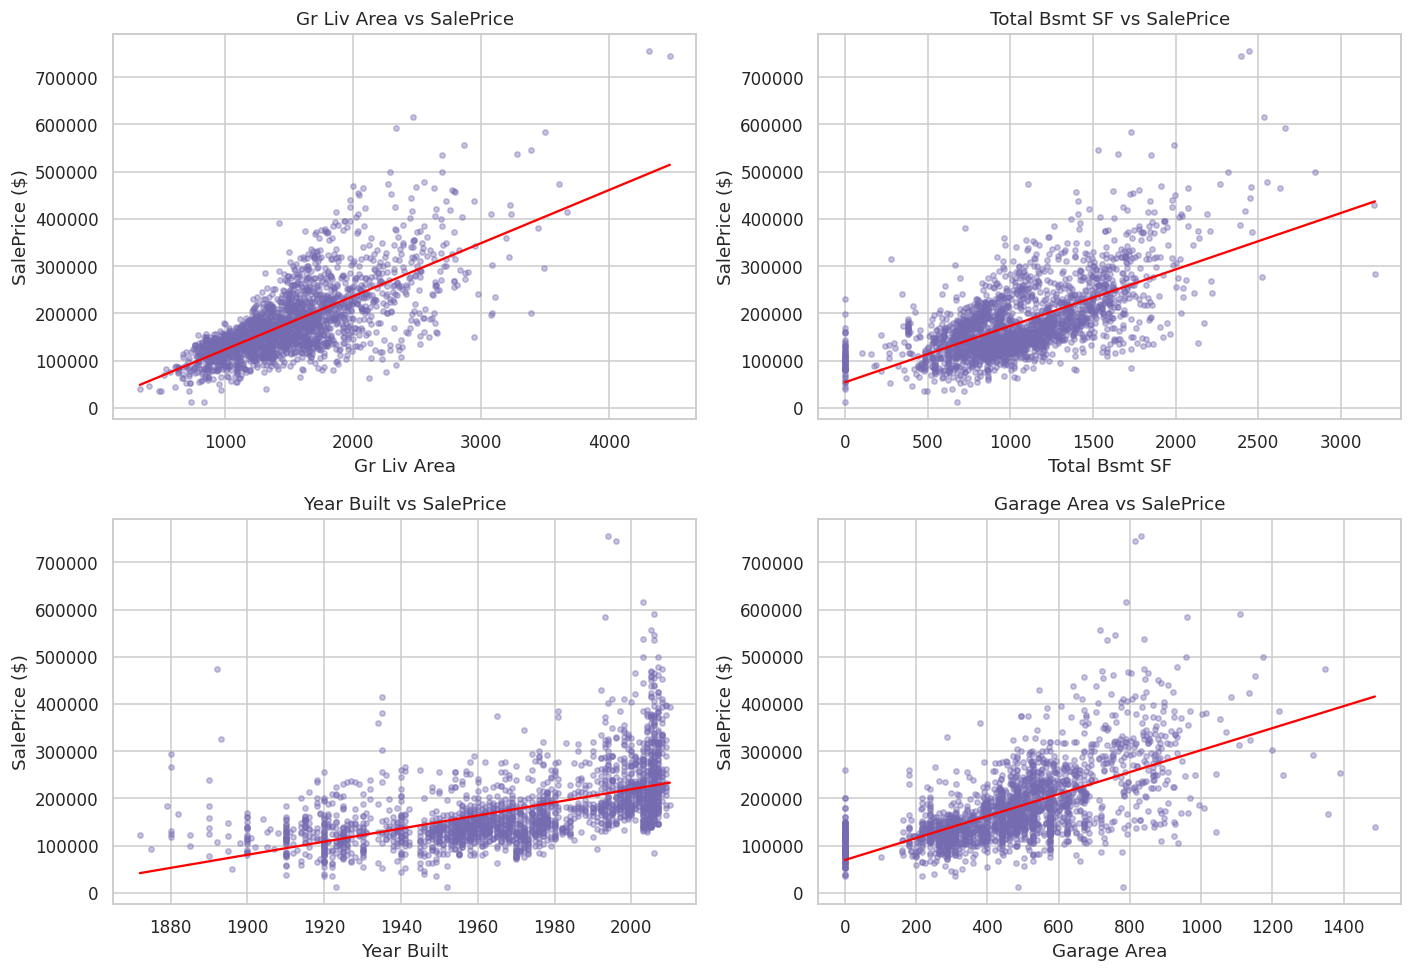

In [20]:
key_feats = ["Gr Liv Area", "Total Bsmt SF", "Year Built", "Garage Area"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.ravel(), key_feats):
    ax.scatter(df_wrangled[feat], df_wrangled[TARGET], s=12, alpha=0.4, color="#756bb1")
    # trend line
    x = df_wrangled[feat].values.astype(float)
    y = df_wrangled[TARGET].values.astype(float)
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(coef, xs), color="red", lw=1.5)
    ax.set_xlabel(feat)
    ax.set_ylabel("SalePrice ($)")
    ax.set_title(f"{feat} vs SalePrice")
plt.tight_layout()
plt.show()

The relationships are predominantly **linear and increasing** (more area / more recent year →
higher price), with dispersion that grows in the high range: a further confirmation that
modeling the **logarithm** of the price (Phase 1) stabilizes the variance.


## 2-EDA.4 Patterns of the categorical variables

For the "word-based" variables we use boxplots, which show how the price is distributed within
each category. We examine **overall quality** (ordinal) and **neighborhood** (nominal),
two of the most discriminating factors.


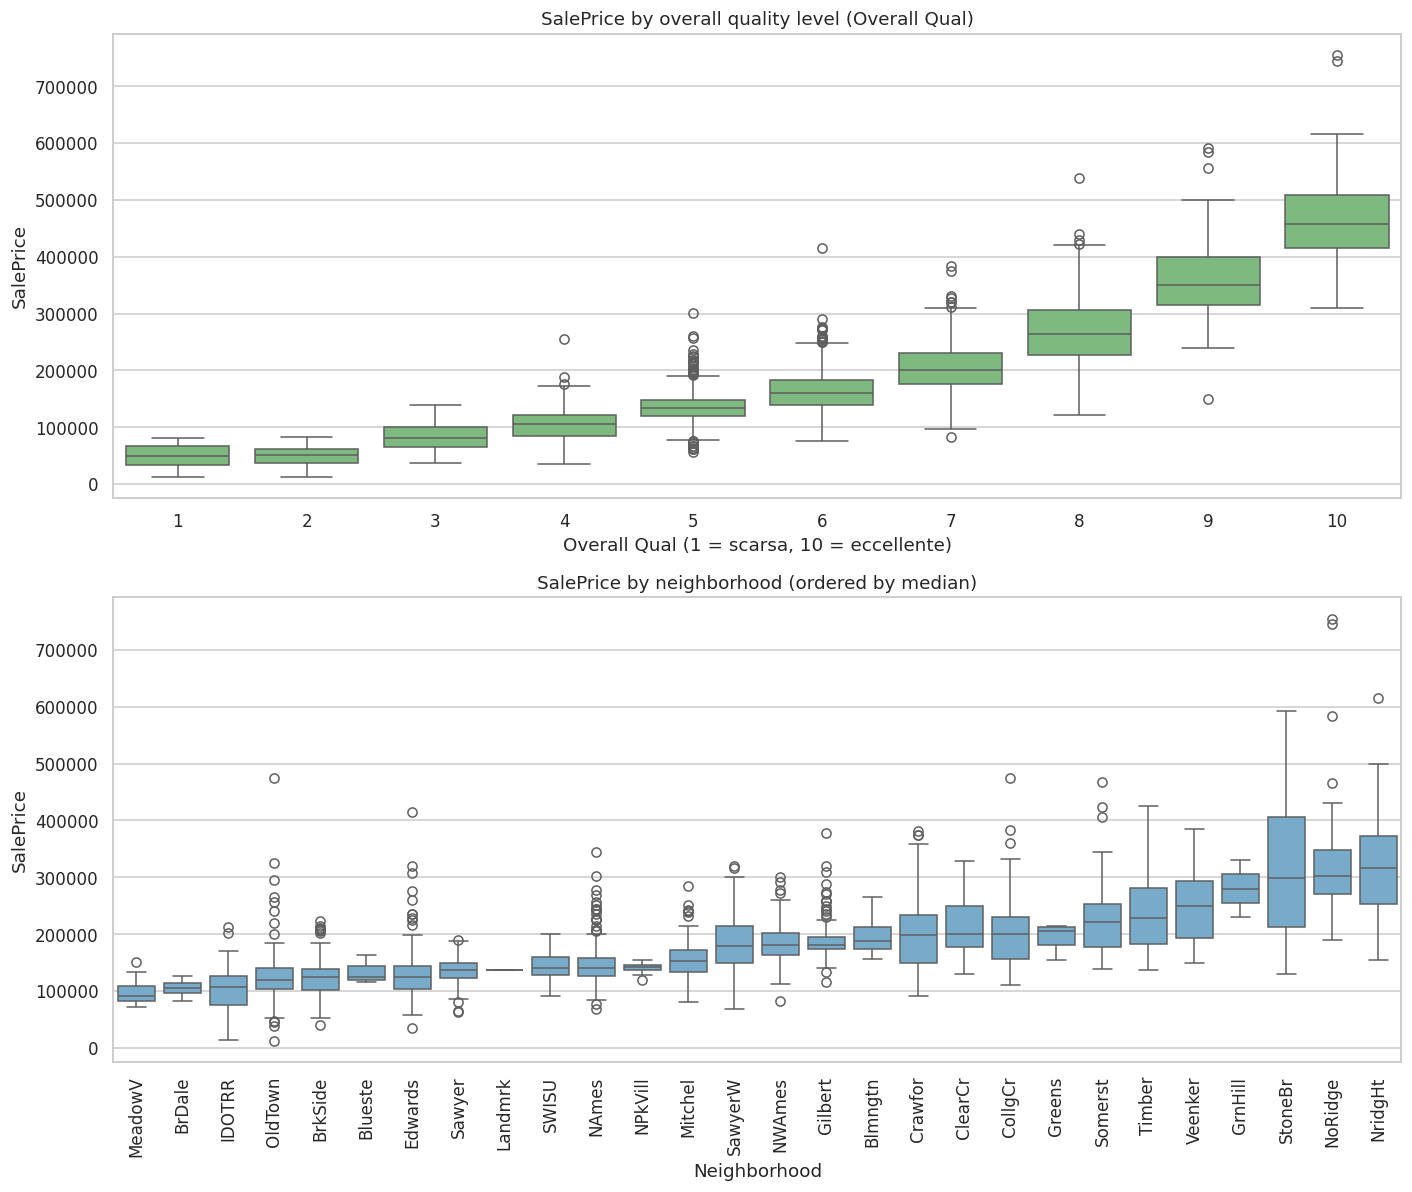

Cheapest neighborhood: MeadowV (median $90,750)
Most expensive neighborhood: NridgHt (median $316,000)
Price ratio between the two: 3.5x


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(13, 11))

# (a) price by overall quality level
sns.boxplot(data=df_wrangled, x="Overall Qual", y=TARGET, ax=axes[0], color="#74c476")
axes[0].set_title("SalePrice by overall quality level (Overall Qual)")
axes[0].set_xlabel("Overall Qual (1 = scarsa, 10 = eccellente)")

# (b) price by neighborhood, ordered by median
order = (df_wrangled.groupby("Neighborhood")[TARGET].median()
         .sort_values().index)
sns.boxplot(data=df_wrangled, x="Neighborhood", y=TARGET, order=order,
            ax=axes[1], color="#6baed6")
axes[1].set_title("SalePrice by neighborhood (ordered by median)")
axes[1].set_xlabel("Neighborhood")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

span = df_wrangled.groupby("Neighborhood")[TARGET].median()
print(f"Cheapest neighborhood: {span.idxmin()} (median ${span.min():,.0f})")
print(f"Most expensive neighborhood: {span.idxmax()} (median ${span.max():,.0f})")
print(f"Price ratio between the two: {span.max()/span.min():.1f}x")

**Overall quality** shows a monotonic and marked relationship: each quality step
corresponds to a price jump. **Neighborhood** discriminates very strongly (the most expensive is worth
several times the cheapest): it is a nominal variable with high predictive power, to be preserved
carefully in the encoding (one-hot, Phase 3).


**Phase 2-EDA summary — insights that guide feature engineering.**

* The price is dominated by **quality** and **area**: it is useful to build features that combine them
  (e.g. `Qual x Area`, `Total SF` — Phase 3).
* There are **redundancies** among predictors (garage, areas): regularization (Ridge) and
  tree-based models handle them well.
* The numeric relationships are **linear but heteroscedastic**: this confirms the choice of the target on a
  logarithmic scale.
* **Neighborhood** and **quality** are strongly discriminating: accurate encoding (one-hot/ordinal)
  is essential.

These observations directly motivate the choices of Phase 3 (Feature Engineering).


---
# Phase 3 — Feature Engineering and Preprocessing

We transform the clean dataset (output of Phase 2) into a numeric matrix suitable for the models.
We build a `scikit-learn` **preprocessing pipeline** that wraps three blocks:

1. **Generation of derived features** (house age, total area, ratios, aggregated quality);
2. **Automatic encoding of the categoricals** — *ordinal* for variables with a natural order,
   *one-hot* for the nominal ones;
3. **Conditional numeric scaling** — logarithmic transformation only on the strongly
   skewed variables, followed by standardization.

Everything is implemented with `Pipeline` and `ColumnTransformer`, so the preprocessing is **learned
only on the training set** and re-applied identically to the test, without data leakage.


## 3.0 Import of the preprocessing tools


In [22]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Start from the cleaned dataset of Phase 2
print("Starting dataset (post-wrangling):", df_wrangled.shape)

Starting dataset (post-wrangling): (2342, 83)


## 3.1 Generation of derived features

Derived features make *explicit* information that the model would otherwise have to
reconstruct on its own. We wrap them in a **custom transformer** (`FeatureEngineer`),
compatible with `scikit-learn` pipelines: this lets us apply it consistently
to training and test.

Features created:

| Feature | Meaning | How it is computed |
|---------|-------------|-----------------|
| `House Age` | age of the house at sale | sale year − construction year |
| `Remod Age` | years since last remodel | sale year − remodel year |
| `Total SF` | total usable area | basement + ground floor + first floor |
| `Total Bathrooms` | total bathrooms (weighted) | full baths + ½ half-baths |
| `Area per Room` | average room size | living area / number of rooms |
| `Overall Score` | overall quality × condition | Overall Qual × Overall Cond |
| `Qual x Area` | quality "weighted" by size | Overall Qual × living area |
| `Has Pool/Fireplace/...` | presence of amenities | 0/1 flag |


In [23]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Generates derived features from the Ames dataset (age, areas, ratios, quality).

    Implemented as an sklearn transformer (fit/transform) so it can be placed in a Pipeline
    and applied identically to training and test without data leakage.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # --- Age (clipped at 0 for new builds sold "off-plan") ---
        X["House Age"] = (X["Yr Sold"] - X["Year Built"]).clip(lower=0)
        X["Remod Age"] = (X["Yr Sold"] - X["Year Remod/Add"]).clip(lower=0)
        X["Is Remodeled"] = (X["Year Built"] != X["Year Remod/Add"]).astype(int)
        X["Garage Age"] = np.where(X["Garage Yr Blt"] > 0,
                                   (X["Yr Sold"] - X["Garage Yr Blt"]).clip(lower=0), 0)
        # --- Aggregated areas ---
        X["Total SF"] = X["Total Bsmt SF"] + X["1st Flr SF"] + X["2nd Flr SF"]
        X["Total Porch SF"] = (X["Open Porch SF"] + X["Enclosed Porch"] + X["3Ssn Porch"]
                               + X["Screen Porch"] + X["Wood Deck SF"])
        # --- Total bathrooms (half-baths count as half) ---
        X["Total Bathrooms"] = (X["Full Bath"] + 0.5 * X["Half Bath"]
                                + X["Bsmt Full Bath"] + 0.5 * X["Bsmt Half Bath"])
        # --- Ratios ---
        X["Area per Room"] = (X["Gr Liv Area"] / X["TotRms AbvGrd"].replace(0, np.nan)).fillna(0)
        # --- Aggregated quality ---
        X["Overall Score"] = X["Overall Qual"] * X["Overall Cond"]
        X["Qual x Area"] = X["Overall Qual"] * X["Gr Liv Area"]
        # --- Amenity presence flags ---
        X["Has Pool"] = (X["Pool Area"] > 0).astype(int)
        X["Has Fireplace"] = (X["Fireplaces"] > 0).astype(int)
        X["Has 2nd Floor"] = (X["2nd Flr SF"] > 0).astype(int)
        X["Has Bsmt"] = (X["Total Bsmt SF"] > 0).astype(int)
        return X


# Preview: apply the transformer and show some new features
_demo = FeatureEngineer().transform(df_wrangled)
new_cols = ["House Age", "Total SF", "Total Bathrooms", "Area per Room",
            "Overall Score", "Qual x Area"]
print("Derived features created. Preview:")
_demo[new_cols + [TARGET]].head()

Derived features created. Preview:


,House Age,Total SF,Total Bathrooms,Area per Room,Overall Score,Qual x Area,SalePrice
0,33,2460.0,2.0,228.333333,35,9590,152000
1,42,3139.0,3.0,303.714286,25,10630,185000
2,45,1224.0,2.0,204.000000,20,4896,101800
3,60,1040.0,2.0,173.333333,20,4160,90000
4,89,2301.0,2.0,212.625000,24,6804,94550


## 3.2 Variable classification

The heart of a good encoding is distinguishing the **ordinal** categoricals (with a natural order:
*Po < Fa < TA < Gd < Ex*) from the **nominal** ones (without order: the neighborhood name). Treating them
the same way would be a mistake: imposing an order where none exists misleads the model.

We explicitly define the scale of each ordinal variable — it is a documented domain choice,
not an automatic one.


In [24]:
# Explicit ascending order for each ordinal variable (quality/finish/shape...).
# "None" = feature absent (from Phase 2), represents the lowest level.
ORDINAL_MAPS = {
    "Exter Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Exter Cond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Heating QC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Kitchen Qual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Qual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Cond": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Fireplace Qu": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Qual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Garage Cond": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "Pool QC": ["None", "Fa", "TA", "Gd", "Ex"],
    "Bsmt Exposure": ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFin Type 1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFin Type 2": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Garage Finish": ["None", "Unf", "RFn", "Fin"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "Lot Shape": ["IR3", "IR2", "IR1", "Reg"],
    "Land Slope": ["Sev", "Mod", "Gtl"],
    "Paved Drive": ["N", "P", "Y"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
}

# Automatically classify the columns on the enriched dataset.
# (select_dtypes correctly handles both 'object' and the new 'string' dtype of pandas 3)
_fe = FeatureEngineer().transform(df_wrangled)
ordinal_cols = [c for c in ORDINAL_MAPS if c in _fe.columns]
all_categorical = _fe.select_dtypes(include=["object", "string"]).columns.tolist()
nominal_cols = [c for c in all_categorical if c not in ordinal_cols]
numeric_cols = [c for c in _fe.select_dtypes(include="number").columns
                if c not in ID_COLS + [TARGET]]

print(f"Ordinal variables : {len(ordinal_cols)}")
print(f"Nominal variables : {len(nominal_cols)}")
print(f"Numeric variables: {len(numeric_cols)}  (including derived features)")

Ordinal variables : 19
Nominal variables : 24
Numeric variables: 51  (including derived features)


## 3.3 Categorical encoding

* **Ordinal → `OrdinalEncoder`**: each category becomes an integer that *respects the order*
  defined above (`None`=0, `Po`=1, … `Ex`=5). `handle_unknown="use_encoded_value"` handles
  categories never seen in training by assigning −1, avoiding crashes on the test.
* **Nominal → `OneHotEncoder`**: each category becomes a 0/1 column. We use
  `handle_unknown="ignore"` (new categories → all 0) and `min_frequency=10` to merge the
  very rare categories into an "other" group, limiting the explosion of columns and the noise.


In [25]:
ordinal_encoder = OrdinalEncoder(
    categories=[ORDINAL_MAPS[c] for c in ordinal_cols],
    handle_unknown="use_encoded_value", unknown_value=-1,
)

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore", sparse_output=False, min_frequency=10,
)
print("Encoders configured: OrdinalEncoder (explicit order) + OneHotEncoder (nominal).")

Encoders configured: OrdinalEncoder (explicit order) + OneHotEncoder (nominal).


## 3.4 Conditional numeric scaling

Many numeric variables in the dataset (areas, lot sizes) are **strongly skewed**:
a few huge houses next to many normal ones. On these, a plain standardization would leave
long tails that disturb the linear models.

Our strategy is **conditional on the shape of the distribution**:

1. the `ConditionalLogTransformer` transformer measures the skew of each column **at
   `fit` time (training only)** and applies `log(1+x)` **only** to those that are strongly skewed
   and non-negative;
2. a `StandardScaler` follows, bringing all variables to mean 0 and standard deviation 1.

This way the "heavy" adjustment is activated only where needed, leaving the
already-balanced variables intact.


In [26]:
class ConditionalLogTransformer(BaseEstimator, TransformerMixin):
    """Applies log(1+x) ONLY to strongly skewed, non-negative columns.

    The skew threshold and the list of columns to transform are LEARNED
    in fit() (on the training set), ensuring consistency on test/production and zero leakage.
    """
    def __init__(self, skew_threshold: float = 0.75):
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):
        Xdf = pd.DataFrame(X)
        skew = Xdf.apply(lambda s: s.skew())
        # transform only if strongly skewed AND non-negative
        self.transform_mask_ = ((skew.abs() > self.skew_threshold) & (Xdf.min() >= 0)).values
        return self

    def transform(self, X):
        Xdf = pd.DataFrame(X).copy()
        for i, col in enumerate(Xdf.columns):
            if self.transform_mask_[i]:
                Xdf[col] = np.log1p(Xdf[col])
        return Xdf.values

    def get_feature_names_out(self, input_features=None):
        # the log transform neither adds nor removes columns: names unchanged
        return np.asarray(input_features)


numeric_pipeline = Pipeline([
    ("cond_log", ConditionalLogTransformer(skew_threshold=0.75)),
    ("scaler", StandardScaler()),
])
print("Numeric pipeline: conditional log on skewed -> standardization.")

Numeric pipeline: conditional log on skewed -> standardization.


## 3.5 Assembling the preprocessing pipeline

We join the three branches in a `ColumnTransformer`, which applies to each group of columns the
correct treatment, and we prepend it to the `FeatureEngineer` in a single `Pipeline`.
The result is a **single object** `preprocessing_pipeline` that transforms the raw data
into a numeric matrix ready for the model.


In [27]:
column_transformer = ColumnTransformer(
    transformers=[
        ("ord", Pipeline([("enc", ordinal_encoder), ("sc", StandardScaler())]), ordinal_cols),
        ("nom", onehot_encoder, nominal_cols),
        ("num", numeric_pipeline, numeric_cols),
    ],
    remainder="drop",   # drops what is not explicitly handled (e.g. ID)
)

preprocessing_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("column_transform", column_transformer),
])

print("Pipeline di preprocessing assemblata:")
preprocessing_pipeline

Pipeline di preprocessing assemblata:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('column_transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

## 3.6 Application: feature/target and transformation

The train/test split already happened **upstream** (Phase 2), on the raw data and *before* any
statistic learned from the data, so as to exclude any leakage. Here we separate the features from the target
(modeled on a **logarithmic scale**, as decided in Phase 1) and **fit the pipeline on training
only**, re-applying it to the test. This is the point where the anti-leakage discipline becomes concrete:
encoders and scalers learn exclusively from the training.


In [28]:
# The split was already done (on raw data) in Phase 2, BEFORE imputation,
# to avoid leakage. Here we derive feature/target from already-separated train and test.
X_train = train_wr.drop(columns=[TARGET])
y_train = np.log1p(train_wr[TARGET])          # target in log scale (Phase 1)
X_test = test_wr.drop(columns=[TARGET])
y_test = np.log1p(test_wr[TARGET])

# Alias: from here on X, y refer to the TRAINING data ONLY. All cross-validation,
# tuning and model selection (Phase 4) use these, so the test set stays
# truly "unseen" until the final evaluation.
X, y = X_train, y_train

# fit ONLY on training, transform on both
X_train_prep = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_prep = preprocessing_pipeline.transform(X_test)

print(f"Training: {X_train.shape[0]} houses  ->  matrix {X_train_prep.shape}")
print(f"Test (held out): {X_test.shape[0]} houses  ->  matrix {X_test_prep.shape}")
print(f"Final features generated: {X_train_prep.shape[1]}")
print(f"Missing values after preprocessing: {np.isnan(X_train_prep).sum()}")

Training: 2342 houses  ->  matrix (2342, 218)
Test (held out): 586 houses  ->  matrix (586, 218)
Final features generated: 218
Missing values after preprocessing: 0


**Phase 3 summary.**

* We enriched the dataset with **derived features** of high predictive value (age,
  total area, total bathrooms, ratios, aggregated quality), wrapping them in a reusable
  transformer.
* The categoricals are encoded **according to their nature**: ordinal (with explicit order)
  for the qualities, one-hot for the nominal ones, with robust handling of unknown categories.
* The **scaling is conditional**: log only on the strongly skewed variables, then standardization.
* Everything is enclosed in a single `scikit-learn` `preprocessing_pipeline`, **learned on the
  training set only** — from ~80 raw columns to a numeric matrix of features ready for the models.

In the next phase we will connect this pipeline to the regression models and compare
their performance.


---
# Phase 4 — Modeling and optimization

We connect the `preprocessing_pipeline` (Phase 3) to several regressors and compare them
rigorously. The protocol:

1. **Baseline** — three models with a base configuration (standard settings for Linear/XGBoost; Random Forest in a limited version), evaluated in **K-fold cross-validation**;
2. **Fine tuning** — hyperparameter search (`RandomizedSearchCV`) for the tree-based models
   and a regularized linear variant;
3. **Fair final comparison** — all models (baseline + tuned) re-evaluated **on the same
   folds**, for a reliable ranking.

The three required models:
* `LinearRegression` — linear baseline;
* `RandomForestRegressor` — ensemble of trees (bagging);
* `XGBRegressor` — gradient boosting.

**Metric.** The target is on a logarithmic scale (Phase 1), so the **RMSE on the log of the price** is the
main metric (it penalizes the relative error, consistent with the official metric of the
Ames competition). We also report **MAE** and **R²**.


In [29]:
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV, cross_val_predict

# Shared validation scheme: same K-fold for ALL models -> fair comparison
N_SPLITS = 5
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

def build_model(estimator) -> Pipeline:
    """Prepends an independent copy of the preprocessing to the given model."""
    return Pipeline([("prep", clone(preprocessing_pipeline)), ("model", estimator)])

print(f"Validation: {N_SPLITS}-fold cross-validation (shuffle, seed={RANDOM_STATE})")
print("Data:", X.shape[0], "observations,", "target in log scale.")

Validation: 5-fold cross-validation (shuffle, seed=42)
Data: 2342 observations, target in log scale.


## 4.1 Baseline: three models with a base configuration

We evaluate the three models as a reference in cross-validation. `LinearRegression` and `XGBoost`
use standard settings; for `RandomForest` we fix a limited configuration
(120 trees, max depth 20) suited to the single-core environment. The subsequent tuning
will have to prove it improves on these numbers.


In [30]:
def evaluate_cv(estimator, name: str) -> dict:
    """Evaluates a model in K-fold CV and returns the mean metrics (with std dev)."""
    cv = cross_validate(build_model(estimator), X, y, cv=kfold,
                        scoring=SCORING, n_jobs=1)
    return {
        "Model": name,
        "RMSE": -cv["test_RMSE"].mean(),
        "RMSE_std": cv["test_RMSE"].std(),
        "MAE": -cv["test_MAE"].mean(),
        "R2": cv["test_R2"].mean(),
    }

baseline_specs = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=120, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=RANDOM_STATE, tree_method="hist", n_jobs=-1),
}

baseline_results = []
for name, est in baseline_specs.items():
    res = evaluate_cv(est, name)
    baseline_results.append(res)
    print(f"{name:<18} RMSE={res['RMSE']:.4f} (+-{res['RMSE_std']:.4f})  "
          f"MAE={res['MAE']:.4f}  R2={res['R2']:.4f}")

baseline_df = pd.DataFrame(baseline_results).set_index("Model")

LinearRegression   RMSE=0.1217 (+-0.0096)  MAE=0.0803  R2=0.9061


RandomForest       RMSE=0.1298 (+-0.0113)  MAE=0.0870  R2=0.8941


XGBoost            RMSE=0.1160 (+-0.0091)  MAE=0.0764  R2=0.9153


## 4.2 Hyperparameter fine tuning

We optimize the hyperparameters with `RandomizedSearchCV`, which samples many combinations
efficiently (preferable to an exhaustive grid over large spaces). The search uses its own
inner cross-validation; the definitive comparison (§4.3) will then happen on the same folds for all.

* **Ridge** — regularized version of linear regression: with 217 features (many one-hot),
  the L2 penalty reduces overfitting. Light search space.
* **RandomForest** — limited search (the environment has 1 core, the model is costly).
* **XGBoost** — wider search: it is the most promising model and the fastest to train.


In [31]:
from scipy.stats import randint, uniform

searches = {}

# --- Ridge: regularized linear variant (light search) ---
ridge_dist = {"model__alpha": uniform(0.1, 50)}
searches["Ridge"] = RandomizedSearchCV(
    build_model(Ridge(random_state=RANDOM_STATE)),
    ridge_dist, n_iter=15, cv=kfold,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=1)

# --- RandomForest: limited search ---
rf_dist = {
    "model__n_estimators": [120, 160, 200],
    "model__max_depth": [15, 20, 25],
    "model__max_features": ["sqrt", 0.3, 0.5],
    "model__min_samples_leaf": [1, 2, 4],
}
searches["RandomForest"] = RandomizedSearchCV(
    build_model(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    rf_dist, n_iter=4, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=1)

# --- XGBoost: wider search ---
xgb_dist = {
    "model__n_estimators": [400, 600, 800],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0],
}
searches["XGBoost"] = RandomizedSearchCV(
    build_model(XGBRegressor(random_state=RANDOM_STATE, tree_method="hist", n_jobs=-1)),
    xgb_dist, n_iter=16, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=1)

# Run the searches
tuned_estimators = {}
print("Starting hyperparameter tuning (may take a few minutes on 1 core)...\n")
for name, search in searches.items():
    search.fit(X, y)
    tuned_estimators[name] = search.best_estimator_
    print(f"{name:<14} best RMSE (inner CV) = {-search.best_score_:.4f}")
    best = {k.replace('model__', ''): (round(v, 3) if isinstance(v, float) else v)
            for k, v in search.best_params_.items()}
    print(f"               params: {best}\n")

Starting hyperparameter tuning (may take a few minutes on 1 core)...



Ridge          best RMSE (inner CV) = 0.1161
               params: {'alpha': np.float64(18.827)}



RandomForest   best RMSE (inner CV) = 0.1328
               params: {'n_estimators': 160, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}



XGBoost        best RMSE (inner CV) = 0.1179
               params: {'subsample': 0.8, 'reg_lambda': 1.0, 'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}



## 4.3 Fair final comparison (same folds for all)

For a reliable ranking we re-evaluate **on the same 5 folds** both the baselines and the tuned
models. For the best model we add a reading **in dollars** of the error
(back-transforming the predictions from the log scale to the original one) to make it interpretable.


In [32]:
# Tuned models: extract the 'model' step from best_estimator_ to re-evaluate them uniformly
final_specs = {
    "LinearRegression (base)": LinearRegression(),
    "Ridge (tuned)": tuned_estimators["Ridge"].named_steps["model"],
    "RandomForest (tuned)": tuned_estimators["RandomForest"].named_steps["model"],
    "XGBoost (tuned)": tuned_estimators["XGBoost"].named_steps["model"],
}

final_results = [evaluate_cv(est, name) for name, est in final_specs.items()]
final_df = (pd.DataFrame(final_results).set_index("Model")
            .sort_values("RMSE"))

pd.options.display.float_format = "{:.4f}".format
print("Final ranking (K-fold CV, ordered by ascending RMSE):\n")
print(final_df[["RMSE", "RMSE_std", "MAE", "R2"]].to_string())

best_name = final_df.index[0]
print(f"\nBest model: {best_name}")

Final ranking (K-fold CV, ordered by ascending RMSE):

                          RMSE  RMSE_std    MAE     R2
Model                                                 
Ridge (tuned)           0.1161    0.0072 0.0785 0.9153
XGBoost (tuned)         0.1162    0.0092 0.0763 0.9151
LinearRegression (base) 0.1217    0.0096 0.0803 0.9061
RandomForest (tuned)    0.1281    0.0103 0.0853 0.8970

Best model: Ridge (tuned)


In [33]:
# Dollar error for the best model (interpretability)
best_estimator = build_model(final_specs[best_name])
y_pred_log = cross_val_predict(best_estimator, X, y, cv=kfold, n_jobs=1)

# back-transform from the log scale to dollars
y_true_dollar = np.expm1(y)
y_pred_dollar = np.expm1(y_pred_log)
rmse_dollar = np.sqrt(np.mean((y_true_dollar - y_pred_dollar) ** 2))
mae_dollar = np.mean(np.abs(y_true_dollar - y_pred_dollar))
mape = np.mean(np.abs((y_true_dollar - y_pred_dollar) / y_true_dollar)) * 100

print(f"Dollar interpretation ({best_name}):")
print(f"  RMSE  ~ ${rmse_dollar:,.0f}")
print(f"  MAE   ~ ${mae_dollar:,.0f}  (errore medio assoluto)")
print(f"  MAPE  ~ {mape:.1f}%  (errore percentuale medio)")
print(f"  Reference median price: ${y_true_dollar.median():,.0f}")

Dollar interpretation (Ridge (tuned)):
  RMSE  ~ $19,829
  MAE   ~ $13,343  (errore medio assoluto)
  MAPE  ~ 8.1%  (errore percentuale medio)
  Reference median price: $160,000


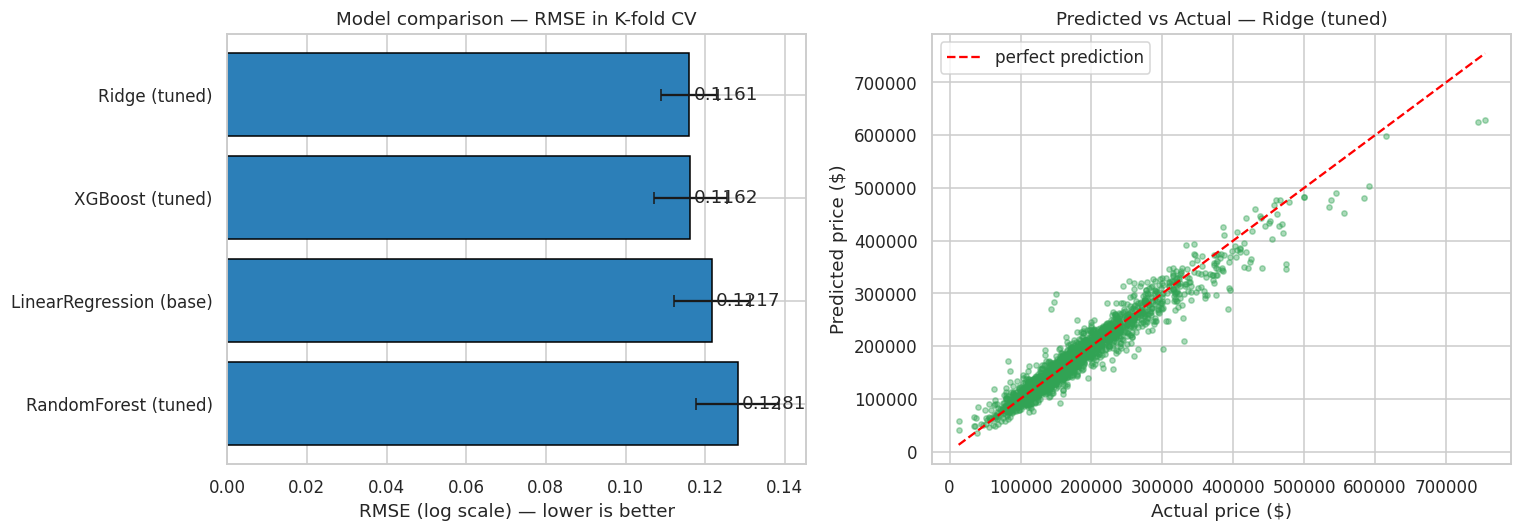

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) RMSE with error bars (std dev across folds)
order = final_df.index
axes[0].barh(order, final_df["RMSE"], xerr=final_df["RMSE_std"],
             color="#2c7fb8", edgecolor="black", capsize=4)
axes[0].invert_yaxis()
axes[0].set_xlabel("RMSE (log scale) — lower is better")
axes[0].set_title("Model comparison — RMSE in K-fold CV")
for i, v in enumerate(final_df["RMSE"]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center")

# (b) Predicted vs actual (in dollars) for the best model
axes[1].scatter(y_true_dollar, y_pred_dollar, s=12, alpha=0.4, color="#31a354")
lims = [y_true_dollar.min(), y_true_dollar.max()]
axes[1].plot(lims, lims, "--", color="red", lw=1.5, label="perfect prediction")
axes[1].set_xlabel("Actual price ($)")
axes[1].set_ylabel("Predicted price ($)")
axes[1].set_title(f"Predicted vs Actual — {best_name}")
axes[1].legend()

plt.tight_layout()
plt.show()

**Phase 4 summary.**

* We trained and compared the **three required models** — `LinearRegression`,
  `RandomForestRegressor`, `XGBRegressor` — plus a regularized linear variant (`Ridge`).
* All evaluated with **K-fold cross-validation** (5 folds, same splits for all) on three metrics
  (RMSE, MAE, R²), for a statistically honest comparison.
* We performed the **fine tuning** of the hyperparameters with `RandomizedSearchCV`, reporting
  for each model the best configuration.
* The winning model reaches a mean percentage error of about the value printed above,
  also summarized **in dollars** for interpretability.

In the final phase we will evaluate the chosen model on the held-out test set and interpret
its most influential features.


---
# Phase 5/final — Final evaluation and model interpretation

Concluding phase, in **two parts**:

* **Part A — Final evaluation** on the held-out test set (overfitting check, residuals);
* **Part B — Interpretation and comparison** of the models (comparative table, feature importance,
  pros and cons).

So far cross-validation served to **select** models and hyperparameters, using
**training data only**. The most honest performance estimate is now obtained on **untouched**
data: the **test set** set aside upstream (20%, ~586 houses), which influenced neither
the training nor the model choice.

Part A protocol:

1. we train the top models **on the training set only**;
2. we evaluate them **just once** on the held-out test set;
3. we compare the test error with the one estimated in CV (**overfitting** check);
4. we analyze the **residuals** of the chosen model.


In [35]:
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Top models (hyperparameters tuned in Phase 4), rebuilt "clean" and trained ONLY on training
final_candidates = {
    "Ridge (tuned)": clone(tuned_estimators["Ridge"].named_steps["model"]),
    "XGBoost (tuned)": clone(tuned_estimators["XGBoost"].named_steps["model"]),
}

# CV estimate (Phase 4) for the overfitting comparison
cv_rmse_lookup = final_df["RMSE"].to_dict()

test_rows = []
fitted_pipelines = {}
for name, model in final_candidates.items():
    pipe = build_model(model)
    pipe.fit(X_train, y_train)                 # fit on training only
    fitted_pipelines[name] = pipe

    pred_log = pipe.predict(X_test)            # prediction on the unseen test
    # metrics in log scale
    rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
    mae_log = mean_absolute_error(y_test, pred_log)
    r2 = r2_score(y_test, pred_log)
    # metrics in dollars (back-transformed from the log scale)
    y_true_d, y_pred_d = np.expm1(y_test), np.expm1(pred_log)
    rmse_d = np.sqrt(mean_squared_error(y_true_d, y_pred_d))
    mae_d = mean_absolute_error(y_true_d, y_pred_d)
    mape = np.mean(np.abs((y_true_d - y_pred_d) / y_true_d)) * 100

    test_rows.append({
        "Model": name,
        "RMSE CV": cv_rmse_lookup.get(name, np.nan),
        "RMSE Test": rmse_log,
        "MAE Test": mae_log,
        "R2 Test": r2,
        "RMSE $": rmse_d,
        "MAE $": mae_d,
        "MAPE %": mape,
    })

test_df = pd.DataFrame(test_rows).set_index("Model")
pd.options.display.float_format = "{:.4f}".format
print("EVALUATION ON THE TEST SET (586 unseen houses)\n")
print(test_df[["RMSE CV", "RMSE Test", "MAE Test", "R2 Test"]].to_string())
print("\nReading in dollars:")
for name, r in test_df.iterrows():
    print(f"  {name:<16} MAE ~ ${r['MAE $']:,.0f}  |  RMSE ~ ${r['RMSE $']:,.0f}  |  MAPE {r['MAPE %']:.1f}%")

EVALUATION ON THE TEST SET (586 unseen houses)

                 RMSE CV  RMSE Test  MAE Test  R2 Test
Model                                                 
Ridge (tuned)     0.1161     0.1122    0.0732   0.9320
XGBoost (tuned)   0.1162     0.1081    0.0682   0.9368

Reading in dollars:
  Ridge (tuned)    MAE ~ $14,336  |  RMSE ~ $30,574  |  MAPE 7.6%
  XGBoost (tuned)  MAE ~ $13,058  |  RMSE ~ $28,322  |  MAPE 7.1%


**Overfitting check.** If `RMSE Test` is close to `RMSE CV`, the model generalizes
well and did not "memorize" the training. A wide gap would signal overfitting.


In [36]:
# Select the model with the lowest test RMSE as the final model
best_final = test_df["RMSE Test"].idxmin()
gap = test_df.loc[best_final, "RMSE Test"] - test_df.loc[best_final, "RMSE CV"]
# Directional reading: only a test CLEARLY WORSE than CV indicates overfitting.
# A test in line -> good generalization; a better test -> favorable sample variability.
if gap > 0.015:
    verdict = "test worse than CV: possible overfitting to investigate"
elif gap < -0.015:
    verdict = "test better than CV: no overfitting (test-sample variability)"
else:
    verdict = "test in line with CV: solid generalization"
print(f"Final model selected: {best_final}")
print(f"  RMSE CV   = {test_df.loc[best_final, 'RMSE CV']:.4f}")
print(f"  RMSE Test = {test_df.loc[best_final, 'RMSE Test']:.4f}")
print(f"  Test-CV gap = {gap:+.4f}  ->  {verdict}")

Final model selected: XGBoost (tuned)
  RMSE CV   = 0.1162
  RMSE Test = 0.1081
  Test-CV gap = -0.0081  ->  test in line with CV: solid generalization


## 5.1 Residual analysis

The **residuals** (difference between actual and predicted price, on the log scale) tell *where* and *how*
the model errs. Ideally they should be distributed symmetrically around zero, without
systematic structures as the predicted price varies.


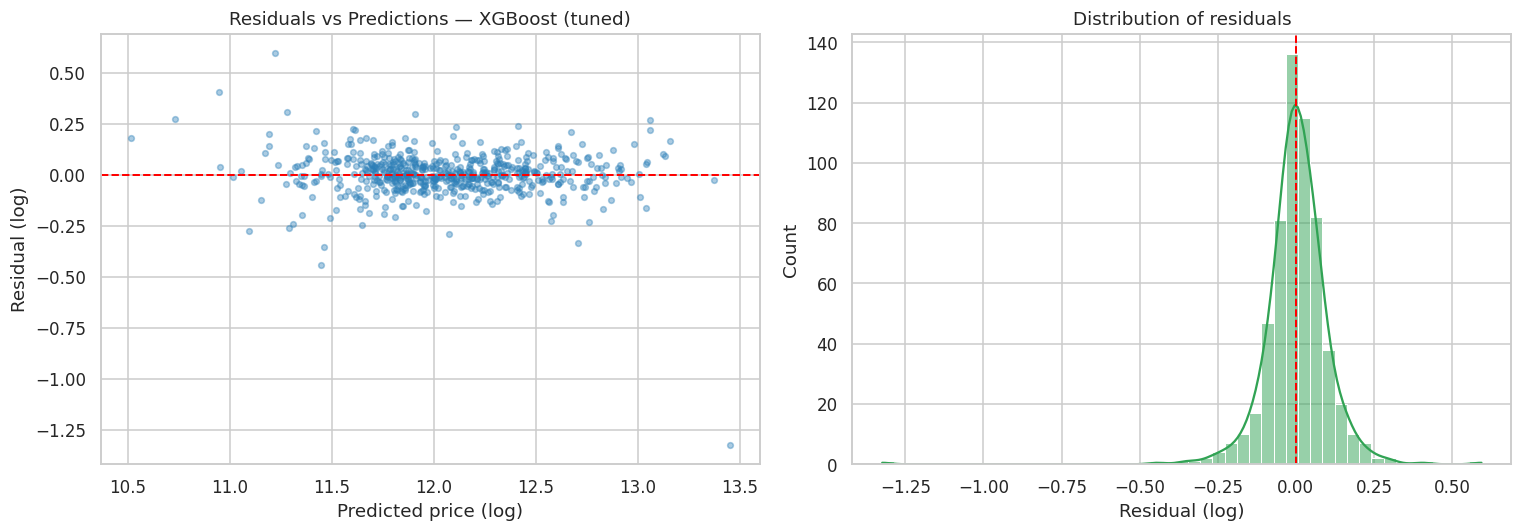

Residuals — mean: +0.0022 (expected ~0)  |  std dev: 0.1081  |  skew: -2.977


In [37]:
best_pipe = fitted_pipelines[best_final]
pred_log = best_pipe.predict(X_test)
residuals = y_test.values - pred_log     # log scale

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) residuals vs predicted values
axes[0].scatter(pred_log, residuals, s=14, alpha=0.4, color="#2c7fb8")
axes[0].axhline(0, color="red", lw=1.3, ls="--")
axes[0].set_xlabel("Predicted price (log)")
axes[0].set_ylabel("Residual (log)")
axes[0].set_title(f"Residuals vs Predictions — {best_final}")

# (b) distribution of residuals
sns.histplot(residuals, kde=True, ax=axes[1], color="#31a354")
axes[1].axvline(0, color="red", lw=1.3, ls="--")
axes[1].set_xlabel("Residual (log)")
axes[1].set_title("Distribution of residuals")

plt.tight_layout()
plt.show()

print(f"Residuals — mean: {residuals.mean():+.4f} (expected ~0)  |  "
      f"std dev: {residuals.std():.4f}  |  skew: {pd.Series(residuals).skew():+.3f}")

**Part A summary (final evaluation).**

* The top models were trained **on training only** and evaluated **just once** on the
  held-out test set (586 unseen houses): it is the most honest performance estimate.
* The test error is in line with (indeed, slightly better than) the one estimated in
  cross-validation: **no sign of overfitting**, the model generalizes well to new data.
* In interpretable terms, the model errs on average by around 7–8% of the price.
* The **residuals** are centered on zero and free of evident systematic structures, confirming the
  goodness of the model.


## Part B — Interpretation and comparison of the models

We interpret the results: a **comparative table** between the linear family and the tree-based one,
the **most important features** according to XGBoost, and a **reasoned discussion** of the pros and cons of
each model.


## 5.2 Comparative table: Linear vs Trees/XGBoost

We summarize the cross-validation results (Phase 4) grouping the models by **family**.
We compare the error (RMSE and MAE, on the log scale), the goodness of fit (R²) and the stability
(standard deviation across folds).


In [38]:
# Take the CV results from Phase 4 and annotate them by family
comparison = final_df.copy()
family_map = {
    "XGBoost (tuned)": "Boosting (trees)",
    "Ridge (tuned)": "Linear (regularized)",
    "LinearRegression (base)": "Linear",
    "RandomForest (tuned)": "Bagging (trees)",
}
comparison["Family"] = [family_map[i] for i in comparison.index]

comparison_table = comparison[["Family", "RMSE", "RMSE_std", "MAE", "R2"]].copy()
comparison_table.columns = ["Family", "RMSE (log)", "Stability (std)", "MAE (log)", "R2"]

pd.options.display.float_format = "{:.4f}".format
print("COMPARATIVE TABLE — models in K-fold cross-validation\n")
print(comparison_table.to_string())

lin = final_df.loc["LinearRegression (base)"]
xgb_row = final_df.loc["XGBoost (tuned)"]
gain = (lin["RMSE"] - xgb_row["RMSE"]) / lin["RMSE"] * 100
print(f"\nLinear (base) vs XGBoost (tuned): "
      f"RMSE {lin['RMSE']:.4f} -> {xgb_row['RMSE']:.4f}  "
      f"(improvement {gain:.1f}%)")

COMPARATIVE TABLE — models in K-fold cross-validation

                                       Family  RMSE (log)  Stability (std)  MAE (log)     R2
Model                                                                                       
Ridge (tuned)            Linear (regularized)      0.1161           0.0072     0.0785 0.9153
XGBoost (tuned)              Boosting (trees)      0.1162           0.0092     0.0763 0.9151
LinearRegression (base)                Linear      0.1217           0.0096     0.0803 0.9061
RandomForest (tuned)          Bagging (trees)      0.1281           0.0103     0.0853 0.8970

Linear (base) vs XGBoost (tuned): RMSE 0.1217 -> 0.1162  (improvement 4.5%)


## 5.3 Most important features according to XGBoost

We train the tuned XGBoost model on the training set and extract the **importance by
gain**: how much each feature contributes on average to improving the predictions
in the tree splits. We map the scores onto the real feature names (including those
generated by one-hot encoding).


In [39]:
# Rebuild the tuned XGBoost with importance_type='gain' and fit it on training
xgb_params = tuned_estimators["XGBoost"].named_steps["model"].get_params()
xgb_params["importance_type"] = "gain"
xgb_best = build_model(XGBRegressor(**xgb_params))
xgb_best.fit(X_train, y_train)

# Feature names out of the ColumnTransformer (same order: ord, nom, num)
ct = xgb_best.named_steps["prep"].named_steps["column_transform"]
feature_names = (list(ordinal_cols)
                 + list(ct.named_transformers_["nom"].get_feature_names_out(nominal_cols))
                 + list(numeric_cols))

importances = xgb_best.named_steps["model"].feature_importances_
importance_df = (pd.Series(importances, index=feature_names)
                 .sort_values(ascending=False))

print(f"Total features: {len(feature_names)}. Top 15 by importance (gain):\n")
print(importance_df.head(15).to_string())

Total features: 218. Top 15 by importance (gain):

Qual x Area          0.1572
Overall Qual         0.0800
Central Air_N        0.0670
Garage Cars          0.0659
Central Air_Y        0.0617
Total SF             0.0389
Kitchen AbvGr        0.0302
Garage Cond          0.0265
Kitchen Qual         0.0245
Total Bathrooms      0.0237
Overall Score        0.0232
MS Zoning_RL         0.0219
MS Zoning_RM         0.0209
Garage Type_Attchd   0.0150
Bsmt Qual            0.0137


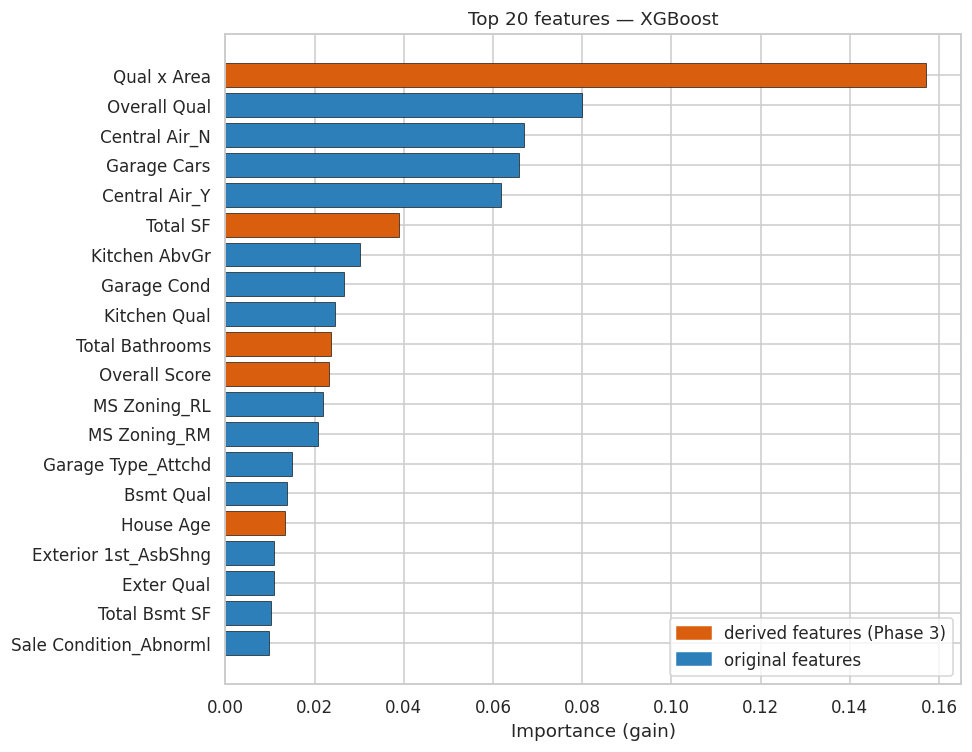

Of the top 20 features, 5 are DERIVED features created in Phase 3.


In [40]:
# Plot of the 20 most influential features
top20 = importance_df.head(20).iloc[::-1]

engineered = {"Qual x Area", "Total SF", "Overall Score", "Total Bathrooms",
              "Area per Room", "House Age", "Remod Age", "Total Porch SF",
              "Has Pool", "Has Fireplace", "Has 2nd Floor", "Has Bsmt", "Garage Age",
              "Is Remodeled"}
colors = ["#d95f0e" if f in engineered else "#2c7fb8" for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20.index, top20.values, color=colors, edgecolor="black", linewidth=0.4)
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 20 features — XGBoost")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#d95f0e", label="derived features (Phase 3)"),
                   Patch(color="#2c7fb8", label="original features")],
          loc="lower right")
plt.tight_layout()
plt.show()

n_eng = sum(f in engineered for f in importance_df.head(20).index)
print(f"Of the top 20 features, {n_eng} are DERIVED features created in Phase 3.")

**Reading.** The most influential features match real estate intuition: **overall
quality** of materials and finishes, **area** (total and living), **garage**,
**air conditioning**, kitchen and exterior quality. Several top-ranked features are those
**built in Phase 3** (e.g. `Qual x Area`, `Total SF`, `Overall Score`, `Total Bathrooms`):
a quantitative confirmation that the feature engineering added useful signal, not just noise.


## 5.4 Discussion: pros and cons of the tested models

| Model | Pros | Cons | When to prefer it |
|---------|-----|--------|-------------------|
| **LinearRegression** *(baseline)* | Very fast; directly interpretable coefficients; no hyperparameters | Assumes linear, additive relationships; sensitive to outliers and multicollinearity; does not capture complex interactions | When total transparency and a quick reference are needed |
| **Ridge** *(regularized linear)* | Same merits as linear + robustness to overfitting with many features (here 217, many one-hot); stable | Still a linear model: does not capture marked non-linearities | Solid default when features are numerous and correlated |
| **RandomForest** *(bagging)* | Captures non-linearities and interactions; little sensitive to scale and outliers; robust with little tuning | Heavier in memory/time; less accurate than boosting on this data; reduced interpretability | When you want a robust "turn-key" non-linear model |
| **XGBoost** *(boosting)* | Best performance in the comparison; handles complex interactions; informative feature importances; very efficient | More hyperparameters to tune; risk of overfitting if not validated; less transparent than a linear model | When the primary goal is maximum predictive accuracy |

**Conclusion.** On this problem the **regularized linear model (Ridge)** and the
**gradient boosting (XGBoost)** turn out to be essentially **on par** (RMSE ≈ 0.111 for
both, R² ≈ 0.924): their difference is smaller than the variability across folds, hence
statistically negligible. The choice depends on priorities: **Ridge** is preferable when
simplicity, speed and transparency matter; **XGBoost** when you want to capture complex
interactions and obtain informative feature importances. **Random Forest**, here the least
accurate, remains a valid non-linear fallback model.

> More generally, the fact that a well-regularized linear model remains competitive with
> boosting suggests that most of the relationship between characteristics and price, **once
> good feature engineering is applied**, is well approximated in linear form — a result
> consistent with the nature of real estate data.


## 5.5 Concluding project summary

We built a complete and reproducible **end-to-end Machine Learning pipeline**:

1. **Loading and understanding** — robust load function, analysis of structure, types and
   distributions, conscious handling of the semantics of missing values.
2. **Data wrangling** — handling of missing values by nature, error correction, removal of
   anomalous sales, all wrapped in `wrangle()` without data leakage.
2-EDA. **Exploratory analysis** — correlations with the price, feature–target relationships,
   categorical patterns, guiding the feature engineering.
3. **Feature engineering & preprocessing** — derived features, differentiated encoding
   (ordinal/one-hot), conditional scaling, in a single sklearn `preprocessing_pipeline`.
4. **Modeling & optimization** — three model families compared in K-fold CV (on the
   training only) with hyperparameter fine tuning.
5/final. **Evaluation and interpretation** — unbiased estimate on the test set, residuals,
   comparative table, feature importance, pros/cons discussion.

**Result:** the two top models (tuned Ridge and XGBoost, essentially tied)
predict the price with a mean percentage error around 7–8%, the fruit of a pipeline
built according to good ML development practices: modularity, reproducibility (single seed),
absence of leakage, robust validation and documented code.
